MIGUEL ANGEL CAMARGO MORA

# 📈 Auditoría Multivariada de Calidad del Aire y Biodiversidad (Bogotá 2021)
### Proyecto Estadística 1 - Antigravity Systems

Este análisis aplica técnicas de inferencia multivariada para diagnosticar la salud atmosférica de Bogotá bajo los estándares de la OMS 2021 y su impacto en la ocupación del ave *Zonotrichia capensis*.

## 📚 Diccionario de Datos

| Variable | Definición | Unidades |
| :--- | :--- | :--- |
| `pm10_ugm3` | Material particulado menor a 10 micras | $\mu g/m^3$ |
| `pm25_ugm3` | Material particulado menor a 2.5 micras | $\mu g/m^3$ |
| `no2_ugm3` | Dióxido de Nitrógeno | $\mu g/m^3$ |
| `so2_ugm3` | Dióxido de Azufre | $\mu g/m^3$ |
| `co_mgm3` | Monóxido de Carbono | $mg/m^3$ |
| `zona` | Región geográfica de Bogotá | Categoría |
| `station_name` | Nombre de la estación de monitoreo | Texto |

In [2]:
!pip install pingouin

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import ipywidgets as widgets
from IPython.display import display, clear_output
from scipy import stats
from statsmodels.multivariate.manova import MANOVA

import warnings
warnings.filterwarnings('ignore')

# Configuración estética
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Lista de contaminantes principales
pollutants = ['pm10_ugm3', 'pm25_ugm3', 'no2_ugm3', 'so2_ugm3', 'co_mgm3']


# Cargar datos
df_daily = pd.read_csv('data/data_diaria_2021.csv')
df_birds = pd.read_csv('data/copeton_2021_multivariate.csv')

# Crear etiqueta combinada para análisis por sitio
df_daily['sitio'] = df_daily['zona'] + " - " + df_daily['station_name']

print(f"Cargados {len(df_daily)} registros diarios y {len(df_birds)} registros de aves.")

Cargados 905 registros diarios y 687 registros de aves.


## 1. Análisis Exploratorio (EDA) Multivariado Detallado

In [4]:
print("### 1.1 Calidad de Datos")
print("\n--- Nulos por Variable ---")
print(df_daily[pollutants].isnull().sum())

print("\n--- Duplicados ---")
print(f"Registros duplicados: {df_daily.duplicated().sum()}")

print("\n--- Desbalance de Muestras por Sitio ---")
print(df_daily.groupby('sitio').size())

### 1.1 Calidad de Datos

--- Nulos por Variable ---
pm10_ugm3    39
pm25_ugm3    54
no2_ugm3     42
so2_ugm3     25
co_mgm3      15
dtype: int64

--- Duplicados ---
Registros duplicados: 0

--- Desbalance de Muestras por Sitio ---
sitio
Centro Oriente - Centro de Alto Rendimiento    239
Noroccidente - Fontibon                        227
Suroccidente - Carvajal - Sevillana            212
Suroriente - Usme                              227
dtype: int64


In [5]:
print("### 1.1.1 Porcentaje de Nulos por Contaminante y Sitio (Tabla)")

# Calcular el porcentaje de nulos por contaminante y por sitio
null_percentages = df_daily.groupby('sitio')[pollutants].apply(lambda x: x.isnull().sum() / len(x) * 100).T

# Transponer el DataFrame para tener los sitios como filas y los contaminantes como columnas
display(null_percentages.T.round(2))

### 1.1.1 Porcentaje de Nulos por Contaminante y Sitio (Tabla)


,pm10_ugm3,pm25_ugm3,no2_ugm3,so2_ugm3,co_mgm3
sitio,,,,,
Centro Oriente - Centro de Alto Rendimiento,0.00,2.93,0.84,5.44,1.26
Noroccidente - Fontibon,3.08,3.52,4.85,3.52,0.88
Suroccidente - Carvajal - Sevillana,12.74,17.92,12.74,0.00,3.77
Suroriente - Usme,2.20,0.44,0.88,1.76,0.88


In [6]:
print("### Análisis de Patrones de Nulos (MCAR)")

# Convertir la columna 'date' a datetime si aún no lo está
df_daily['date'] = pd.to_datetime(df_daily['date'])

# Crear un DataFrame booleano para los nulos
df_nulls = df_daily[pollutants].isnull()
df_nulls['date'] = df_daily['date']
df_nulls['sitio'] = df_daily['sitio']

# Nulos por Mes y Sitio
print("\n--- Nulos por Mes y Sitio ---")
df_nulls['month'] = df_nulls['date'].dt.month
monthly_nulls = df_nulls.groupby(['sitio', 'month'])[pollutants].sum()
display(monthly_nulls)

# Nulos por Día de la Semana y Sitio
print("\n--- Nulos por Día de la Semana y Sitio (0=Lunes, 6=Domingo) ---")
df_nulls['dayofweek'] = df_nulls['date'].dt.dayofweek
daily_nulls = df_nulls.groupby(['sitio', 'dayofweek'])[pollutants].sum()
display(daily_nulls)

print("\n--- Decisión: Eliminación de Nulos ---")
df_daily_cleaned = df_daily.dropna(subset=pollutants).copy()
print(f"Se eliminaron {len(df_daily) - len(df_daily_cleaned)} registros con valores nulos en los contaminantes.")

print("\n--- Balance de Muestras por Sitio después de la Limpieza ---")
# Contar cuántos días quedan por estación (sitio) después de la limpieza
cleaned_sample_balance = df_daily_cleaned.groupby('sitio').size()
display(cleaned_sample_balance)

# Evaluar el desbalance según los criterios mencionados
min_samples = cleaned_sample_balance.min()
max_samples = cleaned_sample_balance.max()

if min_samples > 50 and (min_samples / max_samples) > 0.2:
    print(f"\n✅ El balance de muestras es aceptable. El sitio con menos datos tiene {min_samples} registros ({min_samples / max_samples:.2%} del máximo).")
    print("Se usará 'df_daily_cleaned' para análisis posteriores.")
else:
    print(f"\n⚠️ Advertencia: El balance de muestras podría ser problemático. El sitio con menos datos tiene {min_samples} registros ({min_samples / max_samples:.2%} del máximo).")
    if min_samples <= 50:
        print("Considera que algunos sitios tienen muy pocos registros.")
    print("Se usará 'df_daily_cleaned' para análisis posteriores, pero se recomienda precaución.")


### Análisis de Patrones de Nulos (MCAR)

--- Nulos por Mes y Sitio ---


pm10_ugm3  pm25_ugm3  \
sitio                                       month                         
Centro Oriente - Centro de Alto Rendimiento 1              0          0   
                                            2              0          0   
                                            3              0          4   
                                            4              0          0   
                                            5              0          0   
                                            6              0          3   
                                            7              0          0   
                                            8              0          0   
                                            9              0          0   
                                            10             0          0   
                                            11             0          0   
                                            12             0          0   
Noroccidente - Fontibon                     1              0          2   
                                            2              0          0   
                                            3              0          0   
                                            4              0          0   
                                            5              2          1   
                                            6              4          0   
                                            7              1          2   
                                            8              0          3   
                                            9              0          0   
                                            10             0          0   
                                            11             0          0   
                                            12             0          0   
Suroccidente - Carvajal - Sevillana         1              0          9   
                                            2              0          1   
                                            3              0          0   
                                            4              0          0   
                                            5              0          0   
                                            6              0          0   
                                            7              0          1   
                                            8              0          0   
                                            9              3          3   
                                            10             0          0   
                                            11             0          0   
                                            12            24         24   
Suroriente - Usme                           1              0          0   
                                            2              0          0   
                                            3              0          0   
                                            4              4          0   
                                            5              0          0   
                                            6              0          0   
                                            7              0          0   
                                            8              1          1   
                                            9              0          0   
                                            10             0          0   
                                            11             0          0   
                                            12             0          0   

                                                   no2_ugm3  so2_ugm3  co_mgm3  
sitio                                       month                               
Centro Oriente - Centro de Alto Rendimiento 1             0         1        0  
                                            2            


--- Nulos por Día de la Semana y Sitio (0=Lunes, 6=Domingo) ---


pm10_ugm3  pm25_ugm3  \
sitio                                       dayofweek                         
Centro Oriente - Centro de Alto Rendimiento 0                  0          1   
                                            1                  0          1   
                                            2                  0          2   
                                            3                  0          1   
                                            4                  0          0   
                                            5                  0          1   
                                            6                  0          1   
Noroccidente - Fontibon                     0                  4          2   
                                            1                  1          2   
                                            2                  0          2   
                                            3                  0          1   
                                            4                  1          1   
                                            5                  0          0   
                                            6                  1          0   
Suroccidente - Carvajal - Sevillana         0                  4          4   
                                            1                  3          5   
                                            2                  4          6   
                                            3                  4          7   
                                            4                  4          5   
                                            5                  4          5   
                                            6                  4          6   
Suroriente - Usme                           0                  1          0   
                                            1                  1          0   
                                            2                  1          0   
                                            3                  2          1   
                                            4                  0          0   
                                            5                  0          0   
                                            6                  0          0   

                                                       no2_ugm3  so2_ugm3  \
sitio                                       dayofweek                       
Centro Oriente - Centro de Alto Rendimiento 0                 0         4   
                                            1                 1         1   
                                            2                 1         5   
                                            3                 0         1   
                                            4                 0         0   
                                            5                 0         2   
                                            6                 0         0   
Noroccidente - Fontibon                     0                 1         1   
                                            1                 1         2   
                                            2                 1         1   
                                            3                 2         1   
                                            4                 2         2   
                                            5                 1         1   
                                            6                 3         0   
Suroccidente - Carvajal - Sevillana         0                 4         0   
                                            1                 3         0   
                                            2                 5         0   
                                            3                 4         0   
                                            4                 5         0   
                                            5                 3    


--- Decisión: Eliminación de Nulos ---
Se eliminaron 107 registros con valores nulos en los contaminantes.

--- Balance de Muestras por Sitio después de la Limpieza ---


sitio
Centro Oriente - Centro de Alto Rendimiento    218
Noroccidente - Fontibon                        195
Suroccidente - Carvajal - Sevillana            167
Suroriente - Usme                              218
dtype: int64


✅ El balance de muestras es aceptable. El sitio con menos datos tiene 167 registros (76.61% del máximo).
Se usará 'df_daily_cleaned' para análisis posteriores.


In [7]:
#actualizar datasets
df_original=df_daily.copy()
df_daily=df_daily_cleaned.copy()

In [8]:
print("### 1.2 Estadísticas Descriptivas por Sitio")

def get_descriptive_stats(group):
    stats_dict = {}
    for col in pollutants:
        data = group[col].dropna()
        if len(data) > 0:
            stats_dict[f'{col}_Media'] = data.mean()
            stats_dict[f'{col}_Mediana'] = data.median()
            stats_dict[f'{col}_Varianza'] = data.var()
            stats_dict[f'{col}_Std'] = data.std()
            stats_dict[f'{col}_CV'] = (data.std() / data.mean()) if data.mean() != 0 else np.nan
            stats_dict[f'{col}_Asimetria'] = stats.skew(data)
            stats_dict[f'{col}_Curtosis'] = stats.kurtosis(data)
    return pd.Series(stats_dict)

df_desc = df_daily.groupby('sitio').apply(get_descriptive_stats).T
display(df_desc)

# --- PANEL INTERACTIVO ---
metric_map = {
    'Media': 'Media',
    'Mediana': 'Mediana',
    'Varianza': 'Varianza',
    'Desviación Estándar': 'Std',
    'Coef. Variación (CV)': 'CV',
    'Asimetría': 'Asimetria',
    'Curtosis': 'Curtosis'
}

def actualizar_grafico(Contaminante, Metrica):
    suffix = metric_map[Metrica]
    row_label = f"{Contaminante}_{suffix}"

    data_plot = df_desc.loc[row_label].reset_index()
    data_plot.columns = ['Sitio', 'Valor']

    plt.figure(figsize=(12, 5))
    ax = sns.barplot(x='Sitio', y='Valor', data=data_plot, palette='viridis')
    plt.title(f"Comparativa Multivariada: {Metrica} de {Contaminante}", fontsize=14, fontweight='bold')
    plt.xticks(rotation=15)

    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'),
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha = 'center', va = 'center',
                       xytext = (0, 9),
                       textcoords = 'offset points')
    plt.show()

print("\n--- Explorador Interactivo de Métricas ---")
widgets.interact(actualizar_grafico,
                 Contaminante=pollutants,
                 Metrica=list(metric_map.keys()));

### 1.2 Estadísticas Descriptivas por Sitio


sitio,Centro Oriente - Centro de Alto Rendimiento,Noroccidente - Fontibon,Suroccidente - Carvajal - Sevillana,Suroriente - Usme
pm10_ugm3_Media,22.215556,34.346666,70.772850,38.409857
pm10_ugm3_Mediana,21.839745,33.721544,70.375000,38.299033
pm10_ugm3_Varianza,104.056343,190.068233,345.588810,177.120104
pm10_ugm3_Std,10.200801,13.786524,18.590019,13.308648
pm10_ugm3_CV,0.459174,0.401393,0.262672,0.346490
pm10_ugm3_Asimetria,0.252590,0.401278,-0.048070,0.216771
pm10_ugm3_Curtosis,-0.270547,1.004271,-0.559413,-0.354424
pm25_ugm3_Media,13.759448,18.380549,36.135293,12.513714
pm25_ugm3_Mediana,13.851449,18.428571,36.947368,11.738694
pm25_ugm3_Varianza,41.047959,54.127357,100.634297,55.615958



--- Explorador Interactivo de Métricas ---


interactive(children=(Dropdown(description='Contaminante', options=('pm10_ugm3', 'pm25_ugm3', 'no2_ugm3', 'so2…

### 1.3 Distribuciones KDE por Contaminante y Sitio


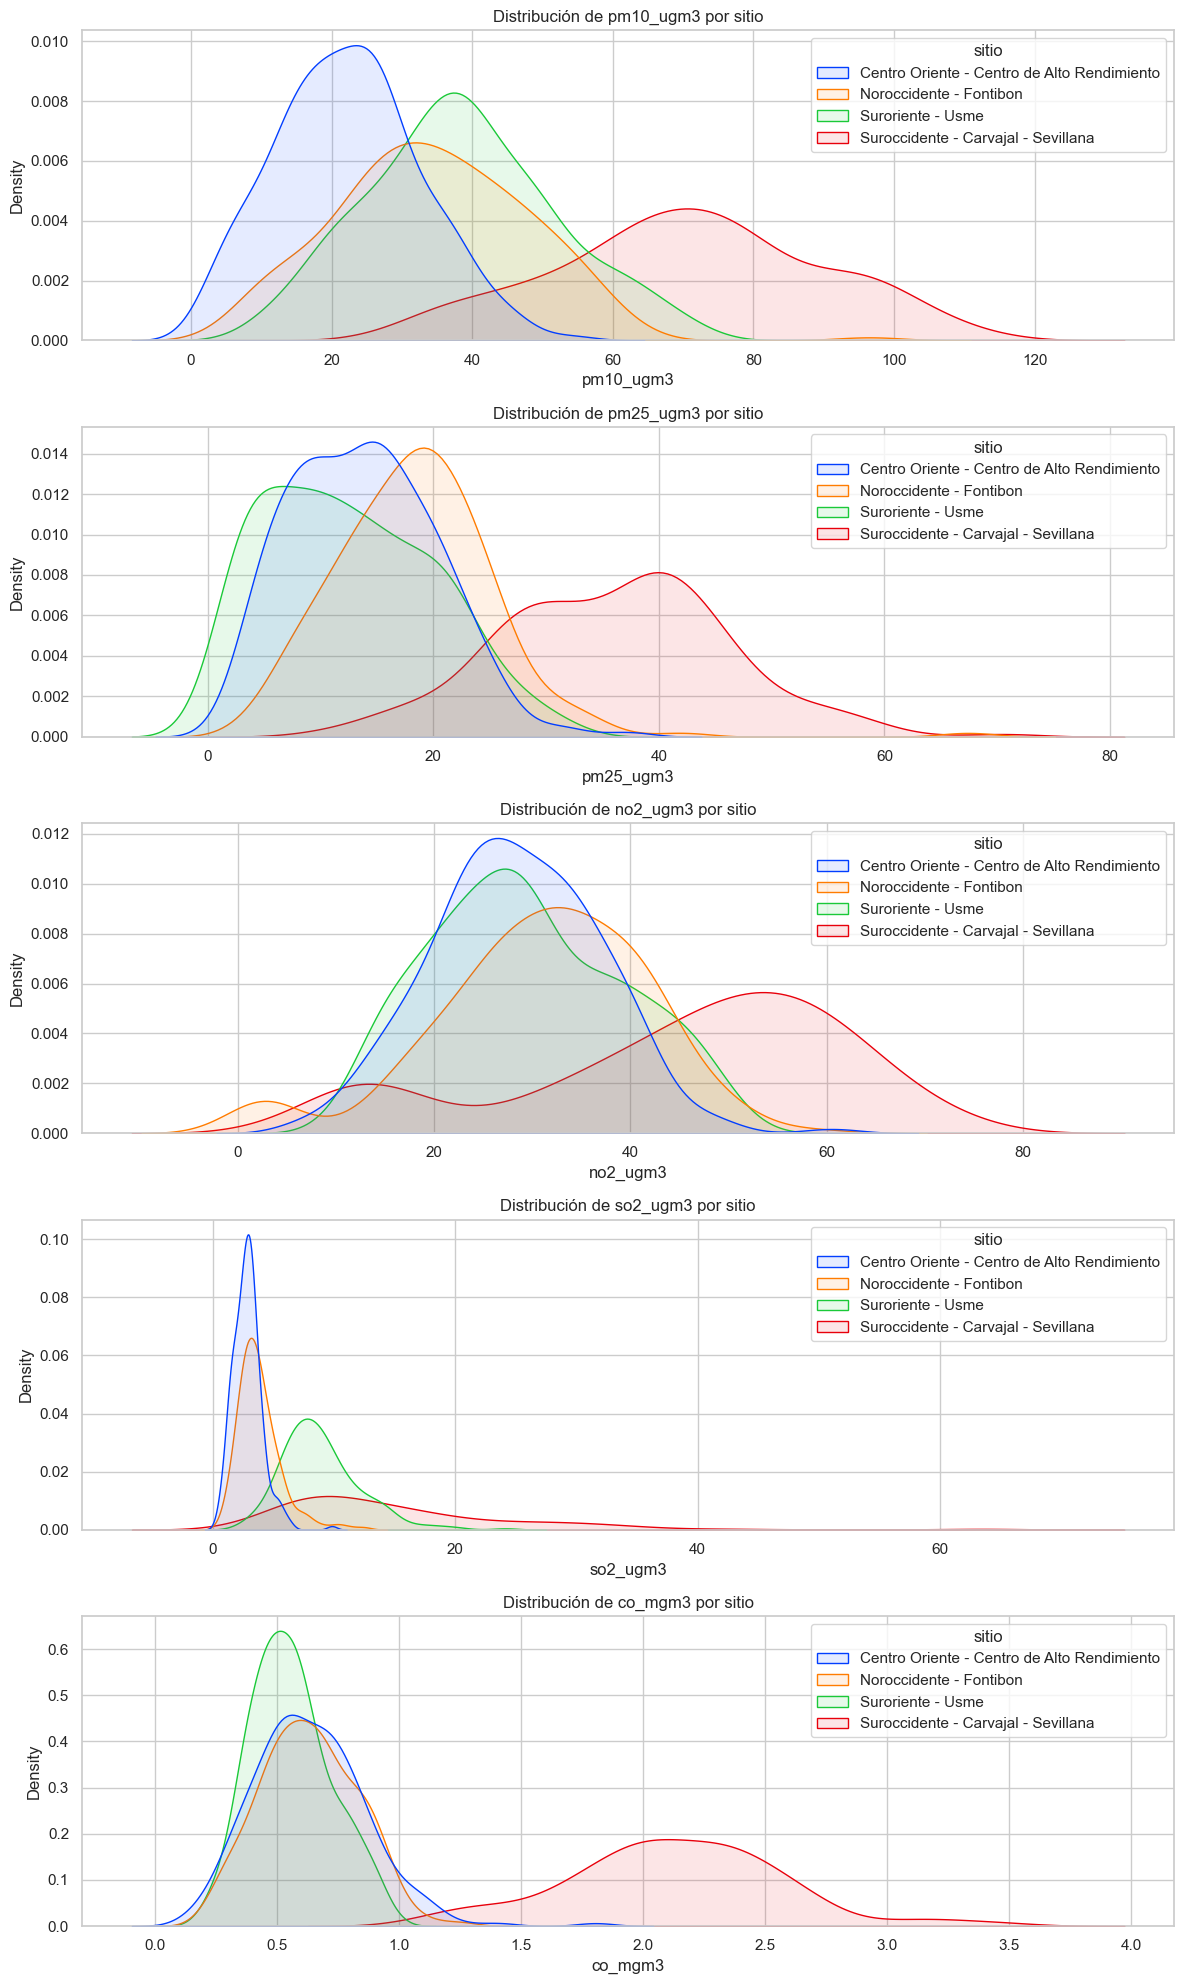

In [9]:
print("### 1.3 Distribuciones KDE por Contaminante y Sitio")
fig, axes = plt.subplots(len(pollutants), 1, figsize=(12, 4 * len(pollutants)))

for i, pol in enumerate(pollutants):
    sns.kdeplot(data=df_daily, x=pol, hue='sitio', palette='bright', fill=True, alpha=0.1, ax=axes[i])
    axes[i].set_title(f"Distribución de {pol} por sitio")

plt.tight_layout()
plt.show()

### 1.4 Boxplots Desagregados por Sitio


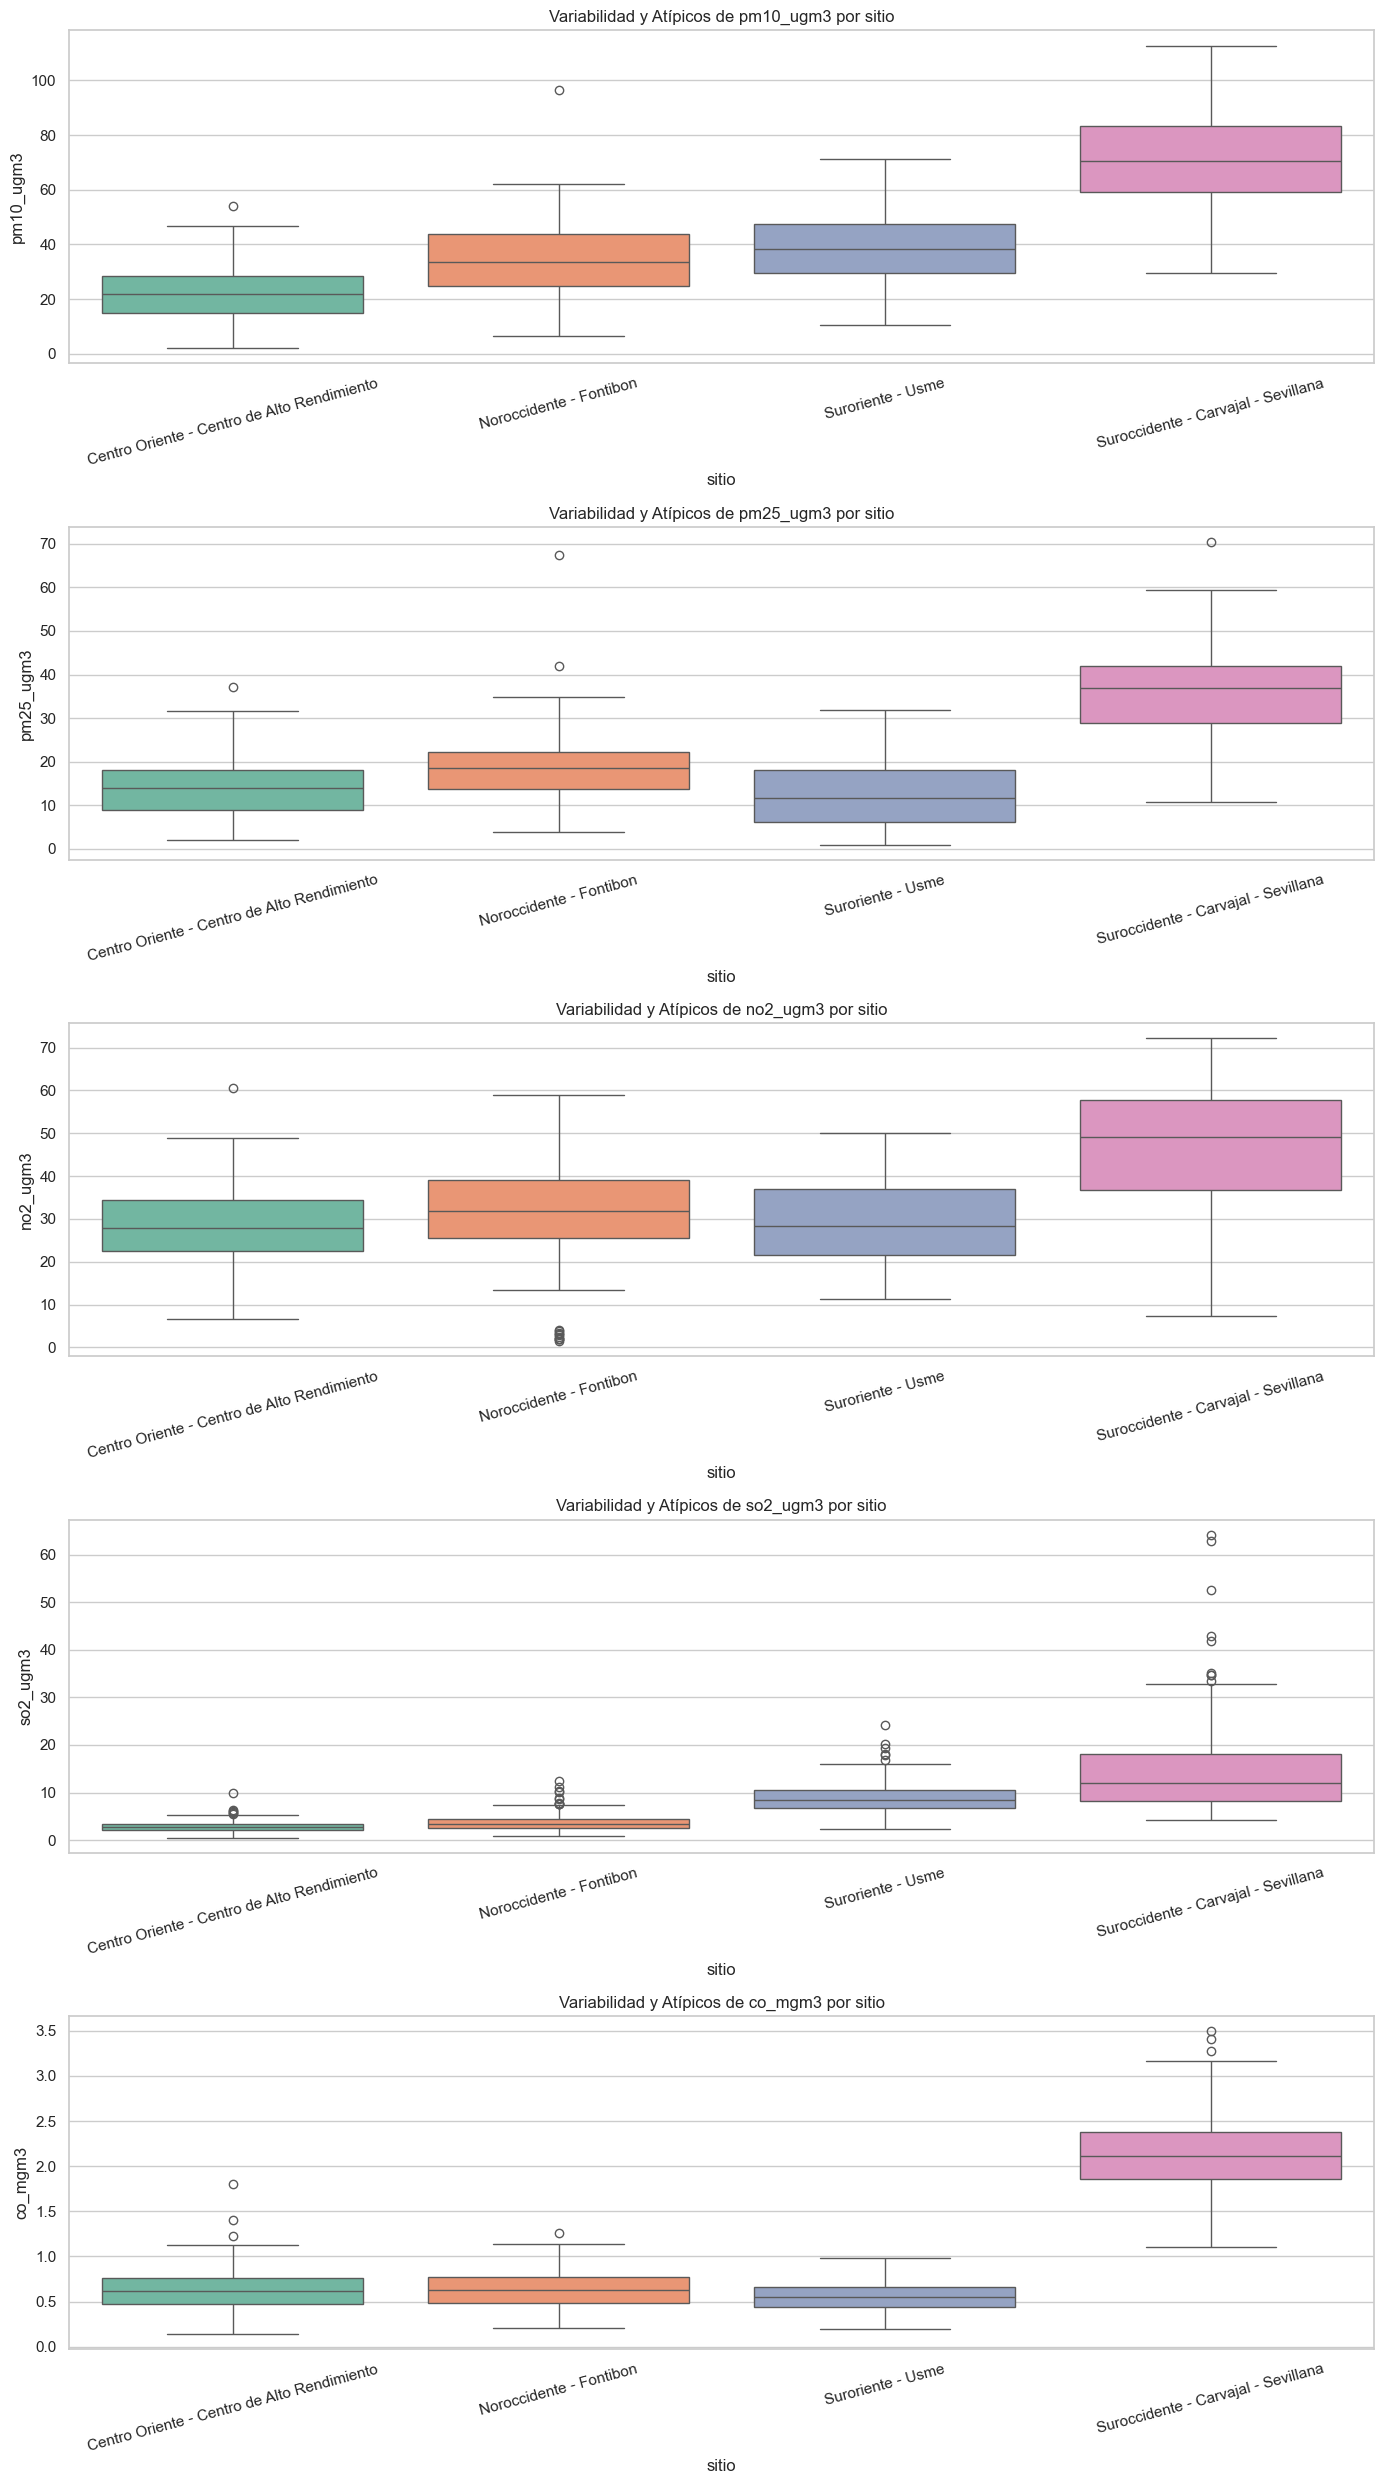

In [10]:
print("### 1.4 Boxplots Desagregados por Sitio")
fig, axes = plt.subplots(len(pollutants), 1, figsize=(14, 5 * len(pollutants)))

for i, pol in enumerate(pollutants):
    sns.boxplot(data=df_daily, x='sitio', y=pol, palette='Set2', ax=axes[i])
    axes[i].set_title(f"Variabilidad y Atípicos de {pol} por sitio")
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 1.5 Comparativa Visual de Matrices de Correlación


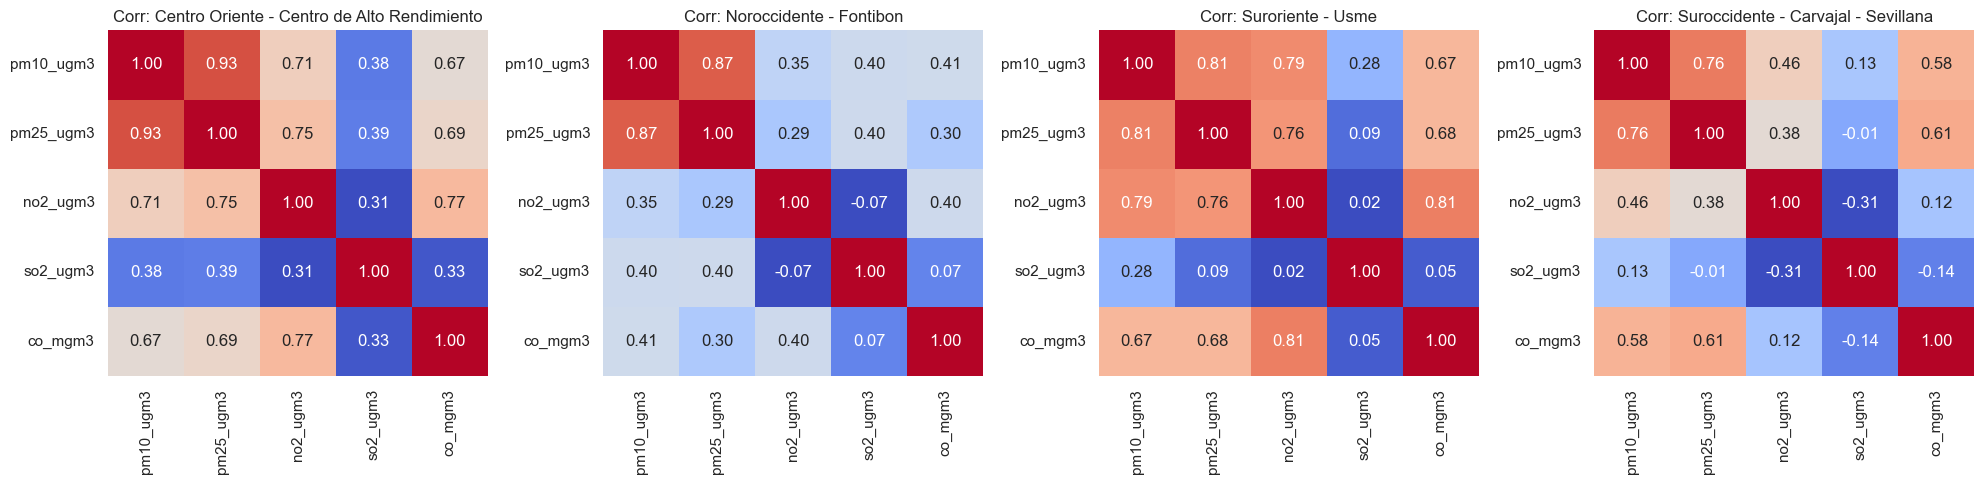

In [11]:
print("### 1.5 Comparativa Visual de Matrices de Correlación")
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

unique_sites = df_daily_cleaned['sitio'].unique()[:4] # Tomamos los  4
for i, site in enumerate(unique_sites):
    data_site = df_daily_cleaned[df_daily_cleaned['sitio'] == site][pollutants]
    if len(data_site) > 0:
        sns.heatmap(data_site.corr(), annot=True, fmt=".2f", cmap='coolwarm', ax=axes[i], cbar=False)
        axes[i].set_title(f"Corr: {site}")

plt.tight_layout()
plt.show()

## PARTE A

### 3.1.1 Explicación Detallada de la Prueba T-cuadrada de Hotelling (Una Muestra)

La prueba T-cuadrada de Hotelling es la extensión multivariada de la prueba t de Student para una muestra. Se utiliza para determinar si el vector de medias de un conjunto de variables dependientes de una muestra es significativamente diferente de un vector de medias poblacionales hipotético (en este caso, los estándares de la OMS).

**Objetivo:** Evaluar si el vector de medias de los contaminantes de un sitio específico (`sample_mean`) es estadísticamente diferente del vector de estándares de la OMS (`mu_oms`).

#### Planteamiento Formal de las Hipótesis:

*   **Hipótesis Nula ($H_0$):** El vector de medias poblacionales verdadero de los contaminantes [pm10, pm25, no2, so2, co] (representado como $\mu$) es igual al vector de los límites máximos de exposición diaria (24 horas) recomendados por la OMS (representado como $\mu_0$).
    Matemáticamente, se postula que:
    $$H_0: \mu = \mu_0$$
    donde $\mu = \begin{pmatrix} \mu_{pm10} \\ \mu_{pm25} \\ \mu_{no2} \\ \mu_{so2} \\ \mu_{co} \end{pmatrix}$ y $\mu_0 = \begin{pmatrix} 45 \\ 15 \\ 25 \\ 40 \\ 4 \end{pmatrix}$

*   **Hipótesis Alternativa ($H_A$):** El vector de medias poblacionales verdadero de los contaminantes ($\mu$) es diferente del vector de estándares de la OMS ($\mu_0$). Es decir, al menos una de las medias de los contaminantes difiere significativamente del estándar de la OMS.
    Matemáticamente, se postula que:
    $$H_A: \mu \neq \mu_0$$

#### Paso a Paso del Cálculo:

1.  **Definir los Parámetros:**
    *   `n`: Número de observaciones en la muestra (número de días). `data.shape[0]`
    *   `p`: Número de variables dependientes (número de contaminantes). `data.shape[1]`
    *   `mu_zero`: Vector de medias hipotéticas bajo la hipótesis nula. **Este vector corresponde a los límites máximos de exposición diaria (24 horas) que recomienda la OMS.**

2.  **Calcular el Vector de Media Muestral ($\bar{X}$):**
    Es el promedio de cada contaminante en la muestra del sitio.
    $\bar{X} = \frac{1}{n} \sum_{i=1}^{n} X_i$
    *Código:* `sample_mean = data.mean(axis=0)`
    
    **Importante:** El orden de los contaminantes en este vector ($\bar{X}$) es el mismo que el definido en la lista `pollutants` (ej: `['pm10_ugm3', 'pm25_ugm3', ..., 'co_mgm3']`).
    Por ejemplo, la media muestral de `pm10_ugm3` se denotaría como $\bar{x}_{pm10}$.

3.  **Calcular la Matriz de Covarianza Muestral (S):**
    Esta matriz describe la variabilidad de cada contaminante y las relaciones (covarianzas) entre ellos dentro de la muestra, sirviendo como estimación de la matriz de covarianza poblacional desconocida.
    $S = \frac{1}{n-1} \sum_{i=1}^{n} (X_i - \bar{X})(X_i - \bar{X})^T$
    *Código:* `sample_cov = data.cov()`

4.  **Calcular la Matriz de Covarianza Inversa ($S^{-1}$):**
    Se necesita la inversa de la matriz de covarianza para el cálculo del estadístico T-cuadrada.
    *Código:* `np.linalg.inv(sample_cov)`

5.  **Calcular el Estadístico T-cuadrada de Hotelling ($T^2$):**
    La fórmula para el estadístico T-cuadrada de Hotelling para una muestra es:
    $T^2 = n (\bar{X} - \mu_0)^T S^{-1} (\bar{X} - \mu_0)$
    Donde: $(\bar{X} - \mu_0)$ es el vector de diferencias entre las medias muestrales y las medias hipotéticas.
    *Código:* `diff = sample_mean - mu_zero`
    *Código:* `t2 = n * diff.T @ cov_inv @ diff`

6.  **Convertir $T^2$ a un Estadístico F:**
    Para comparar el valor de $T^2$ con una distribución conocida y obtener un p-valor, se transforma a un estadístico F-Snedecor. Esta transformación es exacta para datos normales.
    $F = \frac{(n-p)}{(p(n-1))} T^2$
    *Los grados de libertad (df) para esta distribución F son $p$ y $(n-p)$.*
    *Código:* `f_stat = ((n - p) / (p * (n - 1))) * t2`

7.  **Calcular el Valor P:**
    El p-valor es la probabilidad de observar un estadístico F tan extremo o más extremo que el calculado, asumiendo que la hipótesis nula es verdadera (es decir, que no hay diferencia entre el vector de medias del sitio y los estándares de la OMS).
    *Código:* `1 - stats.f.cdf(f_stat, p, n - p)`

8.  **Decisión:**
    *   Si `p_val < alpha` (nivel de significancia, comúnmente 0.05), se rechaza la hipótesis nula. Esto significa que hay evidencia suficiente para concluir que el vector de medias del sitio es significativamente diferente de los estándares de la OMS (es decir, el sitio `INCUMPLE`).
    *   Si `p_val >= alpha`, no se rechaza la hipótesis nula. Esto significa que no hay evidencia suficiente para concluir que el vector de medias del sitio es significativamente diferente de los estándares de la OMS (es decir, el sitio `CUMPLE / Sin evidencia` de incumplimiento significativo).

En la salida del código, verás el **Vector de Media Muestral** y la **Matriz de Covarianza (S)** para cada sitio, seguidos del valor de $T^2$, el estadístico F y el p-valor calculado, junto con la conclusión de cumplimiento.

In [34]:
print("### 3.1 Parte A: Hotelling T2 vs OMS 2021 (Auditoría) - Test de Permutación")

def hotelling_t2_one_sample(data, mu_zero):
    n, p = data.shape
    if n <= p:
        # Not enough data for meaningful covariance matrix or test
        return np.nan, np.nan, np.nan, None, None

    sample_mean = data.mean(axis=0)
    sample_cov = data.cov()
    try:
        cov_inv = np.linalg.inv(sample_cov)
    except np.linalg.LinAlgError:
        # Covariance matrix is singular, cannot invert
        return np.nan, np.nan, np.nan, sample_mean, sample_cov

    diff = sample_mean - mu_zero
    t2 = n * diff.T @ cov_inv @ diff

    # F-statistic and p-value for the parametric version (not used in permutation p-value but still calculated for reference)
    f_stat = ((n - p) / (p * (n - 1))) * t2
    p_val_parametric = 1 - stats.f.cdf(f_stat, p, n - p)
    return t2, f_stat, p_val_parametric, sample_mean, sample_cov

mu_oms = np.array([45, 15, 25, 40, 4])
n_permutations = 5000 # Número de permutaciones para robustez
np.random.seed(42) # Para reproducibilidad de los resultados de permutación

for site in df_daily['sitio'].unique():
    data_site = df_daily[df_daily['sitio'] == site][pollutants].dropna()
    n_obs, p_vars = data_site.shape

    # Verificar si hay suficientes datos para el análisis multivariado (n > p)
    if n_obs <= p_vars:
        print(f"\n--- Sitio: {site} ---")
        print(f"  No hay suficientes datos para realizar la prueba (registros: {n_obs}, variables: {p_vars}).")
        continue

    # 1. Calcular el estadístico T2 observado y obtener medias/covarianzas
    observed_t2, _, _, mean_vec, cov_mat = hotelling_t2_one_sample(data_site, mu_oms)

    if np.isnan(observed_t2):
        print(f"\n--- Sitio: {site} ---")
        print(f"  No se pudo calcular el T2 observado para {site} (posiblemente matriz de covarianza singular).")
        continue

    # 2. Realizar el test de permutación (sign-flipping)
    permuted_t2_stats = []
    centered_data = data_site - mu_oms # Centrar los datos alrededor de la media nula

    for _ in range(n_permutations):
        # Generar signos aleatorios (+1 o -1) para cada observación
        # Multiplicar los datos centrados por estos signos simula la hipótesis nula (media = mu_oms)
        signs = np.random.choice([-1, 1], size=(n_obs, 1)) # vector columna de signos
        permuted_data_mean_centric = mu_oms + (centered_data * signs) # Crear un 'pseudo-muestreo' bajo H0

        # Calcular el T2 para los datos permutados
        perm_mean = permuted_data_mean_centric.mean(axis=0)
        perm_cov = permuted_data_mean_centric.cov()

        try:
            perm_cov_inv = np.linalg.inv(perm_cov)
            perm_diff = perm_mean - mu_oms
            t2_perm = n_obs * perm_diff.T @ perm_cov_inv @ perm_diff
            permuted_t2_stats.append(t2_perm)
        except np.linalg.LinAlgError:
            # Si la matriz de covarianza de una permutación es singular, se omite esa permutación
            continue

    # 3. Calcular el p-valor empírico
    permuted_t2_stats_array = np.array(permuted_t2_stats)
    # Sumar 1 al numerador y al denominador para evitar p-valor de cero y dar una estimación más conservadora
    p_value_perm = (np.sum(permuted_t2_stats_array >= observed_t2) + 1) / (len(permuted_t2_stats_array) + 1)

    # 4. Imprimir resultados
    print(f"\n--- Sitio: {site} ---")
    print(f"  Vector de Media Muestral (x̄):\n{mean_vec.round(2)}")
    print(f"  Matriz de Covarianza (S):\n{cov_mat.round(2)}")
    print(f"  Hotelling T2 Observado = {observed_t2:.2f}")
    print(f"  P-valor (Permutación basado en {len(permuted_t2_stats_array)} simulaciones) = {p_value_perm:.5f} | {'INCUMPLE' if p_value_perm < 0.05 else 'CUMPLE'}")

### 3.1 Parte A: Hotelling T2 vs OMS 2021 (Auditoría) - Test de Permutación

--- Sitio: Centro Oriente - Centro de Alto Rendimiento ---
  Vector de Media Muestral (x̄):
pm10_ugm3    22.22
pm25_ugm3    13.76
no2_ugm3     28.29
so2_ugm3      2.81
co_mgm3       0.63
dtype: float64
  Matriz de Covarianza (S):
           pm10_ugm3  pm25_ugm3  no2_ugm3  so2_ugm3  co_mgm3
pm10_ugm3     104.06      61.03     62.51      4.68     1.59
pm25_ugm3      61.03      41.05     41.29      2.97     1.03
no2_ugm3       62.51      41.29     73.78      3.18     1.52
so2_ugm3        4.68       2.97      3.18      1.43     0.09
co_mgm3         1.59       1.03      1.52      0.09     0.05
  Hotelling T2 Observado = 344617.53
  P-valor (Permutación basado en 5000 simulaciones) = 0.00020 | INCUMPLE

--- Sitio: Noroccidente - Fontibon ---
  Vector de Media Muestral (x̄):
pm10_ugm3    34.35
pm25_ugm3    18.38
no2_ugm3     30.92
so2_ugm3      3.80
co_mgm3       0.63
dtype: float64
  Matriz de Covarianza (S):
      

In [ ]:
print("###  Normalidad Multivariada (Prueba de Mardia)")

for site in df_daily['sitio'].unique():
    data_site = df_daily[df_daily['sitio'] == site][pollutants].dropna()
    if len(data_site) > len(pollutants):
        mardia = pg.multivariate_normality(data_site)
        print(f"{site:.<45} Normal: {mardia.normal} (p={mardia.pval:.5f})")

###  Normalidad Multivariada (Prueba de Mardia)
Centro Oriente - Centro de Alto Rendimiento.. Normal: False (p=0.00000)
Noroccidente - Fontibon...................... Normal: False (p=0.00000)
Suroriente - Usme............................ Normal: False (p=0.00000)
Suroccidente - Carvajal - Sevillana.......... Normal: False (p=0.00000)


# Bootstrap para Hotelling (T^2) vs Estándares OMS

## 🎯 Objetivo

Evaluar si el perfil multivariado de contaminantes en cada sitio difiere de un estándar de referencia:

$$
H_0: \mu = \mu_{OMS}
$$

donde (\mu) es el vector de medias poblacional y (\mu_{OMS}) corresponde a los valores guía.

El contraste se realiza mediante el estadístico de Hotelling’s T-squared.

---

## 🧠 Estadístico utilizado

Para una muestra de tamaño (n) con (p) variables:

$$
T^2 = n (\bar{x} - \mu_0)^T S^{-1} (\bar{x} - \mu_0)
$$

donde:

* (\bar{x}): media muestral
* (\mu_0): vector de referencia (OMS)
* (S): matriz de covarianza muestral

---

## ⚠️ Limitación del enfoque paramétrico

El test clásico de (T^2) asume:

* Normalidad multivariada
* Homogeneidad de covarianza
* Ausencia de outliers

Dado que estos supuestos no suelen cumplirse en datos ambientales, se emplea un enfoque bootstrap.

---

## 💡 Idea del Bootstrap

El bootstrap aproxima la distribución del estadístico bajo la hipótesis nula sin asumir normalidad.

Para ello:

> Se generan muestras artificiales donde la media es igual a (\mu_{OMS}), preservando la estructura de los datos.

---

## 🔧 Procedimiento Paso a Paso

### 1. Cálculo del estadístico observado

Para cada sitio:

* Se calcula (\bar{x}) y (S)
* Se obtiene:

$$
T^2_{obs} = n (\bar{x} - \mu_{OMS})^T S^{-1} (\bar{x} - \mu_{OMS})
$$

---

### 2. Construcción de datos bajo (H_0)

Se transforman los datos originales:

$$
X_i^* = X_i - \bar{x} + \mu_{OMS}
$$

Esto asegura que:

$$
\mathbb{E}[X^*] = \mu_{OMS}
$$

---

### 3. Remuestreo bootstrap

Para (b = 1, \dots, B):

* Se seleccionan (n) observaciones con reemplazo de (X^*)
* Se obtiene una muestra bootstrap (X^{*(b)})

---

### 4. Cálculo del estadístico bootstrap

Para cada muestra:

$$
T^2_b = n (\bar{x}^{*(b)} - \mu_{OMS})^T S_b^{-1} (\bar{x}^{*(b)} - \mu_{OMS})
$$

---

### 5. Construcción de la distribución empírica

Se obtiene:

$$
{T^2_1, T^2_2, \dots, T^2_B}
$$

Esto representa la distribución de (T^2) bajo (H_0).

---

### 6. Cálculo del p-valor

$$
p = \frac{\sum_{b=1}^{B} \mathbb{I}(T^2_b \geq T^2_{obs}) + 1}{B + 1}
$$

---

## 📊 Interpretación

* Si (p < 0.05):
  ❌ Se rechaza (H_0) → el perfil de contaminación difiere del estándar OMS

* Si (p \geq 0.05):
  ✅ No hay evidencia suficiente para rechazar (H_0)

---

## ✅ Ventajas del método

* No requiere normalidad multivariada
* Robusto a asimetría
* Adecuado para datos ambientales reales
* Preserva la estructura de correlación de los datos

---

## ⚠️ Consideraciones

* Se requiere (n > p)
* Sensible a outliers extremos
* Requiere múltiples iteraciones (costo computacional)

---

## 🚀 Idea clave

> El bootstrap simula cómo se comportaría el estadístico si la media fuera igual al estándar, utilizando la estructura real de los datos.

---

## 📌 Conclusión

El uso de bootstrap con el estadístico (T^2) permite realizar inferencia multivariada robusta frente a violaciones de los supuestos clásicos, siendo especialmente útil en el análisis de calidad del aire.


In [32]:
import numpy as np

print("### 3.1 Parte A: Hotelling T2 vs OMS 2021 - Bootstrap")

def hotelling_t2_one_sample(data, mu_zero):
    data = np.asarray(data)
    n, p = data.shape

    if n <= p:
        return np.nan, None, None

    mean_vec = np.mean(data, axis=0)
    cov_mat = np.cov(data, rowvar=False)
    cov_inv = np.linalg.pinv(cov_mat)

    diff = mean_vec - mu_zero
    t2 = n * diff.T @ cov_inv @ diff

    return t2, mean_vec, cov_mat


# Parámetros
mu_oms = np.array([45, 15, 25, 40, 4])
B = 5000
np.random.seed(42)

for site in df_daily['sitio'].unique():
    data_site = df_daily[df_daily['sitio'] == site][pollutants].dropna().values
    n_obs, p_vars = data_site.shape

    print(f"\n--- Sitio: {site} ---")

    if n_obs <= p_vars:
        print(f"  No hay suficientes datos (n={n_obs}, p={p_vars})")
        continue

    # 1. T2 observado
    observed_t2, mean_vec, cov_mat = hotelling_t2_one_sample(data_site, mu_oms)

    if np.isnan(observed_t2):
        print("  Error en cálculo de T2")
        continue

    # 2. Centrar datos bajo H0
    centered_data = data_site - mean_vec + mu_oms

    bootstrap_t2 = []

    for _ in range(B):
        # Remuestreo con reemplazo
        sample_idx = np.random.choice(n_obs, n_obs, replace=True)
        bootstrap_sample = centered_data[sample_idx]

        t2_boot, _, _ = hotelling_t2_one_sample(bootstrap_sample, mu_oms)

        if not np.isnan(t2_boot):
            bootstrap_t2.append(t2_boot)

    bootstrap_t2 = np.array(bootstrap_t2)

    # 3. p-valor bootstrap
    p_value_boot = (np.sum(bootstrap_t2 >= observed_t2) + 1) / (len(bootstrap_t2) + 1)

    # 4. Resultados
    print(f"  Media muestral (x̄):\n{np.round(mean_vec, 2)}")
    print(f"  Hotelling T² observado = {observed_t2:.2f}")
    print(f"  p-valor (bootstrap) = {p_value_boot:.5f}")

    if p_value_boot < 0.05:
        print("  ❌ Evidencia de incumplimiento (μ ≠ μ_OMS)")
    else:
        print("  ✅ No hay evidencia de incumplimiento")

### 3.1 Parte A: Hotelling T2 vs OMS 2021 - Bootstrap

--- Sitio: Centro Oriente - Centro de Alto Rendimiento ---
  Media muestral (x̄):
[22.22 13.76 28.29  2.81  0.63]
  Hotelling T² observado = 344617.53
  p-valor (bootstrap) = 0.00020
  ❌ Evidencia de incumplimiento (μ ≠ μ_OMS)

--- Sitio: Noroccidente - Fontibon ---
  Media muestral (x̄):
[34.35 18.38 30.92  3.8   0.63]
  Hotelling T² observado = 176306.48
  p-valor (bootstrap) = 0.00020
  ❌ Evidencia de incumplimiento (μ ≠ μ_OMS)

--- Sitio: Suroriente - Usme ---
  Media muestral (x̄):
[38.41 12.51 29.33  8.87  0.56]
  Hotelling T² observado = 317235.81
  p-valor (bootstrap) = 0.00020
  ❌ Evidencia de incumplimiento (μ ≠ μ_OMS)

--- Sitio: Suroccidente - Carvajal - Sevillana ---
  Media muestral (x̄):
[70.77 36.14 45.05 15.33  2.12]
  Hotelling T² observado = 14446.43
  p-valor (bootstrap) = 0.00020
  ❌ Evidencia de incumplimiento (μ ≠ μ_OMS)


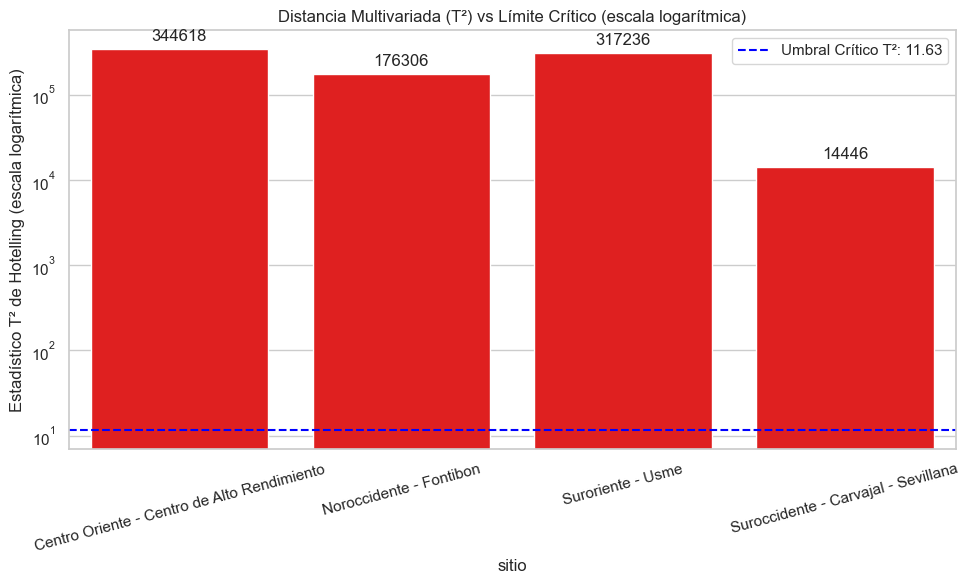

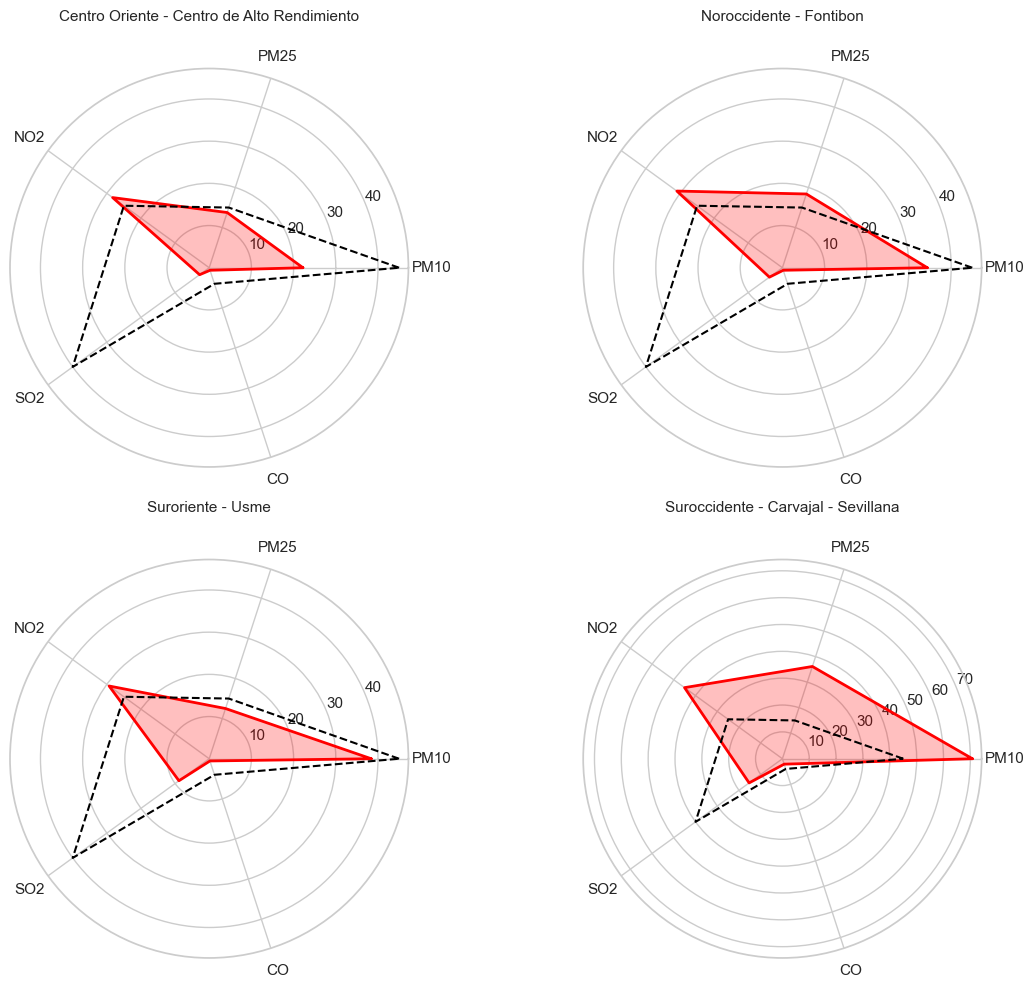

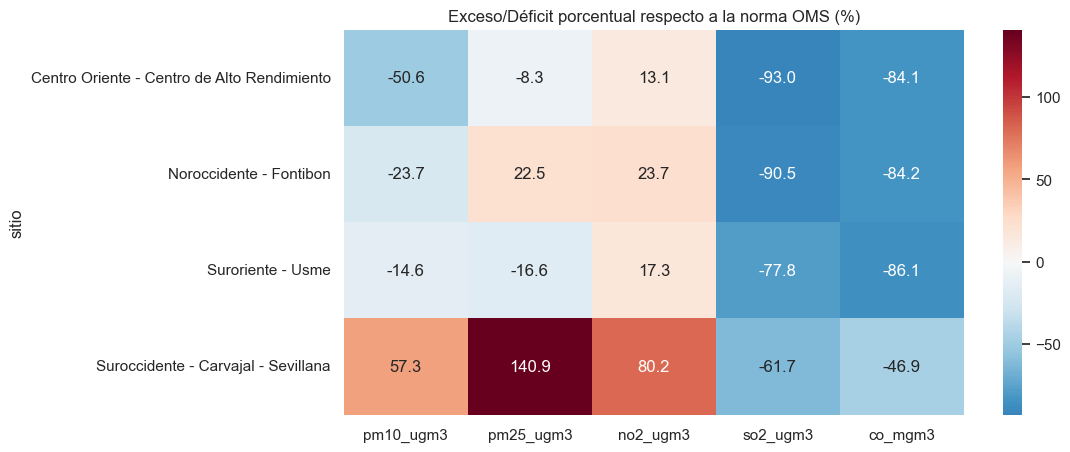

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Recolectar resultados
results = []
pollutants = ['pm10_ugm3', 'pm25_ugm3', 'no2_ugm3', 'so2_ugm3', 'co_mgm3']

for site in df_daily_cleaned['sitio'].unique():
    data_site = df_daily_cleaned[df_daily_cleaned['sitio'] == site][pollutants].dropna()
    n, p = data_site.shape

    if n > p:
        # Asumiendo que hotelling_t2_one_sample devuelve: t2, f, p_val, mean_vec, cov
        t2_stat, f_stat, p_val, sample_mean_vec, _ = hotelling_t2_one_sample(data_site, mu_oms)
        if not np.isnan(p_val):
            row = {'sitio': site, 'n': n, 'p': p, 't2_stat': t2_stat, 'f_stat': f_stat, 'p_val': p_val}
            # Corrección: Asegurar que extraemos los valores en el orden correcto
            for pol in pollutants:
                row[f'{pol}_mean'] = sample_mean_vec[pol]
            results.append(row)

df_resumen = pd.DataFrame(results)

# --- 1. Gráfico de Barras T² ---
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='sitio', y='t2_stat', data=df_resumen, hue='sitio',
            palette=['red' if p < 0.05 else 'green' for p in df_resumen['p_val']], legend=False)

# Añadir etiquetas de valor a las barras
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

# Cálculo de T² Crítico (usando n promedio o mínimo para referencia)
n_ref = df_resumen['n'].min()
p_dim = len(pollutants)
f_crit = stats.f.ppf(1 - 0.05, p_dim, n_ref - p_dim)
t2_crit = (p_dim * (n_ref - 1) / (n_ref - p_dim)) * f_crit

plt.axhline(t2_crit, color='blue', linestyle='--', label=f'Umbral Crítico T²: {t2_crit:.2f}')
plt.title('Distancia Multivariada (T²) vs Límite Crítico (escala logarítmica)')
plt.xticks(rotation=15)
plt.legend()
plt.yscale('log') # Aplicar escala logarítmica
plt.ylabel('Estadístico T² de Hotelling (escala logarítmica)')
plt.tight_layout()
plt.show()

# --- 2. Gráfico de Araña (Radar) ---
# Optimizamos para mostrar promedios reales comparados con la OMS
def make_radar(df_row, ax, color, title):
    categories = pollutants
    n_vars = len(categories)
    angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
    angles += angles[:1]

    # Valores del sitio
    values = [df_row[f'{p}_mean'] for p in pollutants]
    values += values[:1]

    # Valores OMS (Referencia)
    oms_plot = mu_oms.tolist()
    oms_plot += oms_plot[:1]

    ax.plot(angles, values, color=color, linewidth=2, label=title)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.plot(angles, oms_plot, color='black', linestyle='--', label='Límite OMS')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['PM10', 'PM25', 'NO2', 'SO2', 'CO'])
    ax.set_title(title, size=11, y=1.1)

# Configuración de malla dinámica según número de sitios
n_sites = len(df_resumen)
cols = 2
rows = (n_sites + 1) // 2
fig, axes = plt.subplots(figsize=(12, rows*5), nrows=rows, ncols=cols, subplot_kw=dict(polar=True))
axes = axes.flatten()

for i, (idx, row) in enumerate(df_resumen.iterrows()):
    color = 'red' if row['p_val'] < 0.05 else 'green'
    make_radar(row, axes[i], color, row['sitio'])

# Limpiar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# --- 3. Heatmap de Desviación ---
# Calculamos la desviación porcentual de forma vectorizada
df_means = df_resumen[[f'{p}_mean' for p in pollutants]].values
deviation_pct = ((df_means - mu_oms) / mu_oms) * 100
df_heat = pd.DataFrame(deviation_pct, index=df_resumen['sitio'], columns=pollutants)

plt.figure(figsize=(10, 5))
sns.heatmap(df_heat, annot=True, fmt=".1f", cmap='RdBu_r', center=0)
plt.title('Exceso/Déficit porcentual respecto a la norma OMS (%)')
plt.show()

### **Interpretación de los Gráficos de Araña (Radar Charts)**

Los gráficos de araña son herramientas visuales que te permiten comparar múltiples variables cuantitativas en dos o más grupos. Son particularmente útiles para identificar patrones y perfiles.

#### **1. Las Dimensiones (los 'radios' o 'ejes')**

*   **¿Qué representan?** Cada uno de los 'radios' o 'ejes' que parten del centro de la gráfica representa una de tus variables, en este caso, cada contaminante (`pm10_ugm3`, `pm25_ugm3`, `no2_ugm3`, `so2_ugm3`, `co_mgm3`).
*   **Escala:** La distancia desde el centro a lo largo de cada radio indica el valor de ese contaminante. Cuanto más lejos del centro se encuentre un punto en un radio, mayor es el valor de ese contaminante.
*   **Comparación entre dimensiones:** Permite ver rápidamente si un grupo tiene valores altos en ciertos contaminantes y bajos en otros. Por ejemplo, en el gráfico de la **Parte A**, puedes ver el perfil de cada estación de monitoreo y cómo se compara el nivel de cada contaminante con el límite de la OMS (la línea punteada negra).
    *   **Ejemplo:** Si la línea de una estación se extiende más allá de la línea negra punteada en el radio de `pm25_ugm3`, significa que esa estación tiene un promedio de `pm25_ugm3` superior al estándar de la OMS.

#### **2. El Área (la 'forma' o 'polígono' coloreado)**

*   **¿Qué representa?** El área encerrada por la línea que conecta los puntos de cada dimensión forma un polígono. Este polígono representa el **perfil general** o la **'magnitud' multivariada** del grupo en cuestión. Una forma más grande indica generalmente valores más altos en los contaminantes, mientras que una forma más pequeña sugiere valores más bajos.
*   **Comparación de perfiles:** Te permite comparar la 'huella' de contaminación de diferentes grupos (estaciones o presencia/ausencia de aves). Si los polígonos de dos grupos son muy diferentes en forma o tamaño, esto sugiere una diferencia significativa en sus perfiles de contaminantes.
    *   **Ejemplo 1 (Parte A - Auditoría vs OMS):** En los gráficos de araña que comparan cada estación con el límite de la OMS, un polígono grande que envuelve la línea de la OMS indica un incumplimiento generalizado. Las estaciones que muestran polígonos que se extienden significativamente más allá de la línea de la OMS en varios radios tienen un perfil de contaminación más severo.
    *   **Ejemplo 2 (Parte C - Efecto Biológico):** En el 'Snake Plot' o gráfico de araña que compara la presencia (verde) y ausencia (naranja) del copetón con datos estandarizados, se busca ver si los polígonos tienen formas o áreas claramente distintas. Si los polígonos están muy superpuestos o tienen formas similares, como en este caso, esto respalda la conclusión de que no hay una diferencia significativa en el perfil de contaminación entre los dos grupos.

#### **En resumen:**

*   **Radios:** Para entender los niveles de cada contaminante individual.
*   **Área/Forma:** Para comprender el perfil multivariado general y las diferencias o similitudes entre grupos.

Estas visualizaciones son una forma excelente de complementar las pruebas estadísticas, ya que te ofrecen una perspectiva intuitiva de los resultados.

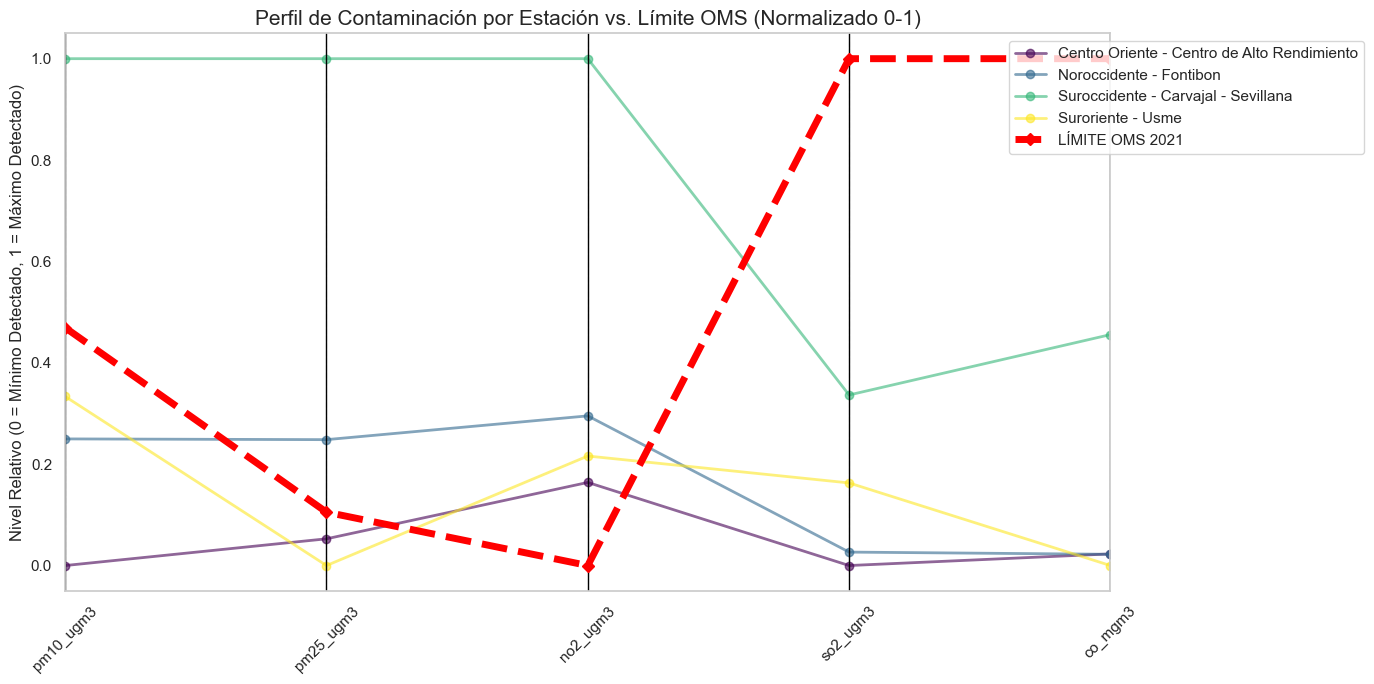

In [15]:
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparar datos y el vector OMS
df_parallel = df_daily_cleaned.copy()
mu_oms = [45, 15, 25, 40, 4] # PM10, PM25, NO2, SO2, CO

# Creamos un DataFrame temporal que incluya la fila de la OMS para normalizar todo junto
df_oms = pd.DataFrame([mu_oms], columns=pollutants)
df_oms['sitio'] = 'ESTÁNDAR OMS'

# 2. Calcular promedios por sitio
df_means = df_parallel.groupby('sitio')[pollutants].mean().reset_index()

# Combinamos promedios con la fila OMS antes de escalar
df_combined = pd.concat([df_means, df_oms], ignore_index=True)

# 3. Escalar (Normalización 0-1)
scaler_mm = MinMaxScaler()
df_combined[pollutants] = scaler_mm.fit_transform(df_combined[pollutants])

# 4. Graficar
plt.figure(figsize=(14, 7))
ax = plt.gca() # Get current axes

# Graficamos primero las estaciones
parallel_coordinates(
    df_combined[df_combined['sitio'] != 'ESTÁNDAR OMS'],
    'sitio',
    colormap='viridis',
    linewidth=2,
    alpha=0.6,
    marker='o',
    ax=ax # Ensure it uses the same axes
)

# Graficamos la línea de la OMS con un estilo sobresaliente (Rojo y Grueso)
oms_row_scaled = df_combined[df_combined['sitio'] == 'ESTÁNDAR OMS'][pollutants].iloc[0]

# The x-coordinates for parallel plot are just indices (0 to p-1)
num_vars = len(pollutants)
x_coords = range(num_vars)

ax.plot(
    x_coords,
    oms_row_scaled,
    color='red',
    linewidth=5,
    linestyle='--',
    marker='D',
    label='LÍMITE OMS 2021' # Now the label is passed to ax.plot directly
)

# Set x-ticks and labels explicitly after parallel_coordinates might have set them
ax.set_xticks(x_coords)
ax.set_xticklabels(pollutants, rotation=45)

plt.title('Perfil de Contaminación por Estación vs. Límite OMS (Normalizado 0-1)', fontsize=15)
plt.ylabel('Nivel Relativo (0 = Mínimo Detectado, 1 = Máximo Detectado)')
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## PARTE B

In [16]:
!pip install scikit-bio

**Validación de Supuestos Multivariados**


### 2.1 Normalidad Multivariada (Prueba de Mardia)
Centro Oriente - Centro de Alto Rendimiento.. Normal: False (p=0.00000)
Noroccidente - Fontibon...................... Normal: False (p=0.00000)
Suroriente - Usme............................ Normal: False (p=0.00000)
Suroccidente - Carvajal - Sevillana.......... Normal: False (p=0.00000)

### 2.2 Gráfico Q-Q de Mahalanobis (Visualización de la Normalidad)


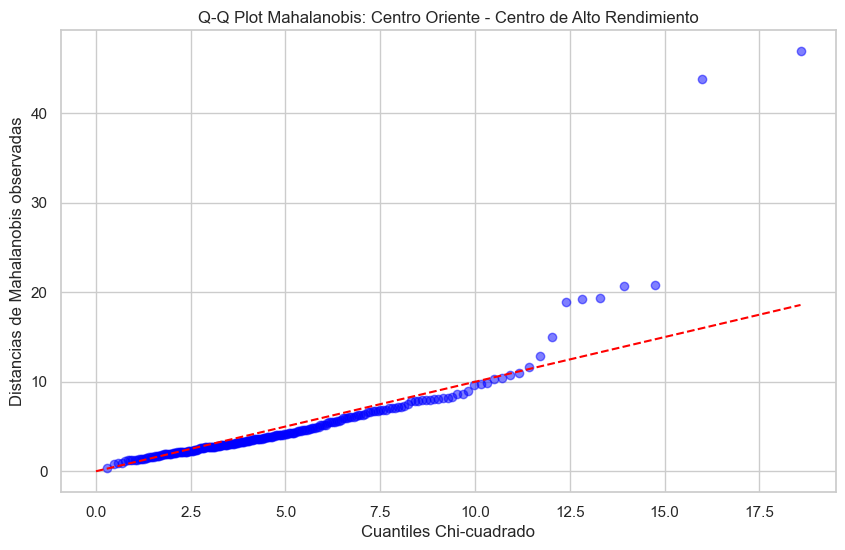

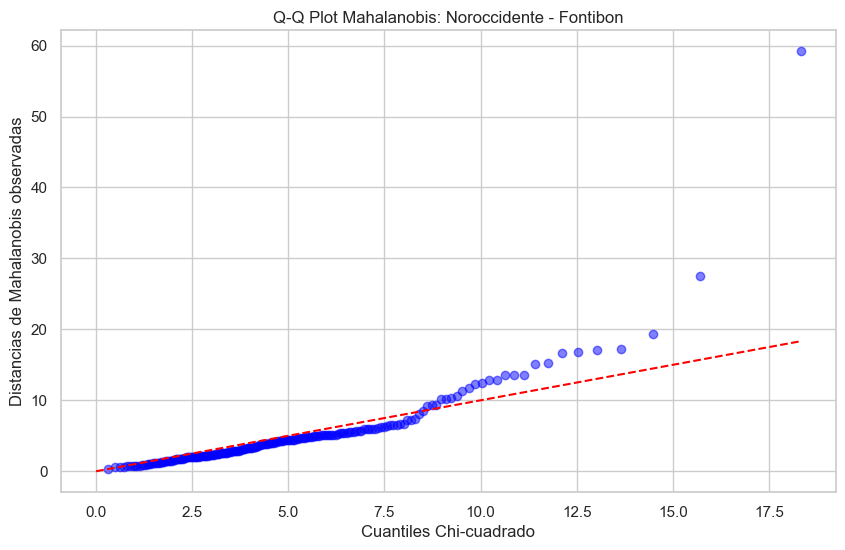

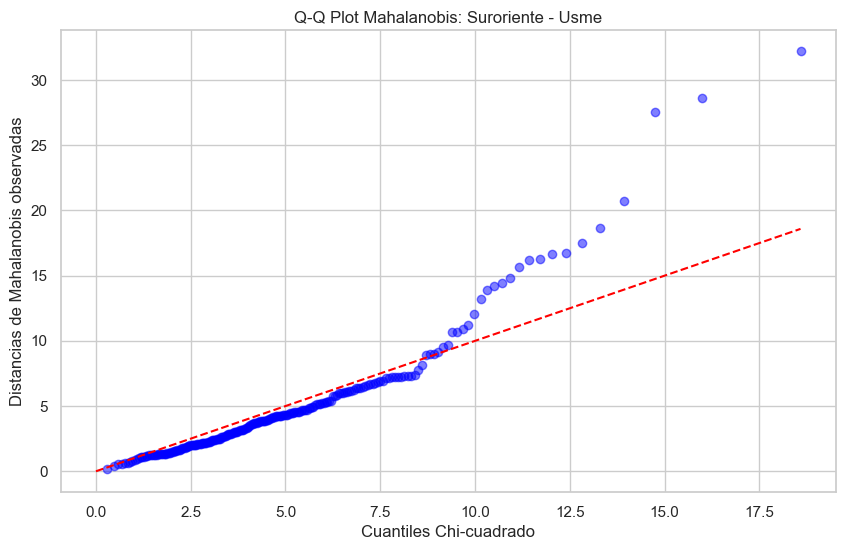

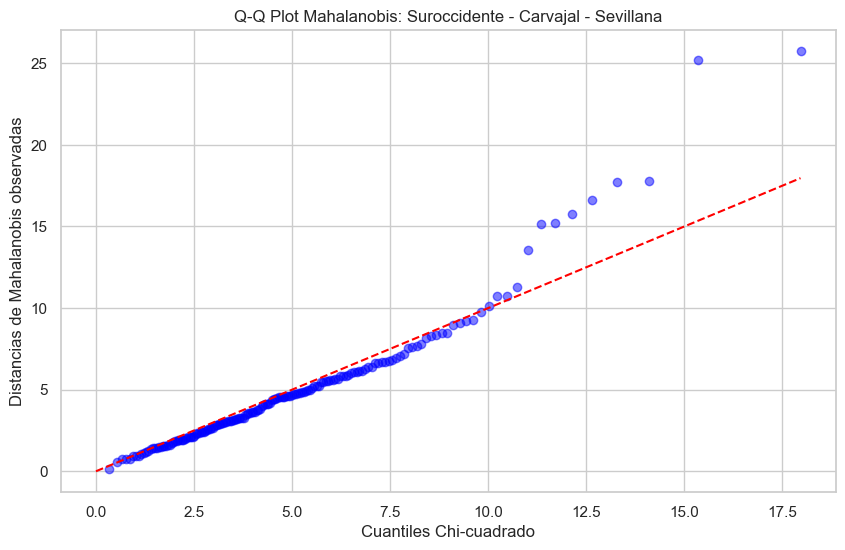

In [17]:
print("### 2.1 Normalidad Multivariada (Prueba de Mardia)")

for site in df_daily['sitio'].unique():
    data_site = df_daily[df_daily['sitio'] == site][pollutants].dropna()
    if len(data_site) > len(pollutants):
        mardia = pg.multivariate_normality(data_site)
        print(f"{site:.<45} Normal: {mardia.normal} (p={mardia.pval:.5f})")

print("\n### 2.2 Gráfico Q-Q de Mahalanobis (Visualización de la Normalidad)")

def plot_mahalanobis_qq(data, title):
    mu = data.mean(axis=0)
    S = data.cov()
    S_inv = np.linalg.inv(S)

    d_sq = []
    for _, row in data.iterrows():
        diff = row - mu
        d_sq.append(diff.T @ S_inv @ diff)

    d_sq = sorted(d_sq)
    n = len(d_sq)
    p = data.shape[1]
    chi2_quantiles = stats.chi2.ppf([(i - 0.5) / n for i in range(1, n + 1)], df=p)

    plt.scatter(chi2_quantiles, d_sq, color='blue', alpha=0.5)
    plt.plot([0, max(chi2_quantiles)], [0, max(chi2_quantiles)], color='red', linestyle='--')
    plt.title(f"Q-Q Plot Mahalanobis: {title}")
    plt.xlabel("Cuantiles Chi-cuadrado")
    plt.ylabel("Distancias de Mahalanobis observadas")
    plt.show()

# Nuevo código implementado:
for site in df_daily['sitio'].unique():
    data_site = df_daily[df_daily['sitio'] == site][pollutants].dropna()
    if len(data_site) > len(pollutants):
        plot_mahalanobis_qq(data_site, site)


In [18]:
print("### 2.3 Homocedasticidad Multivariada (Prueba M de Box)")
try:
    # Aseguramos que no haya nulos en las variables involucradas
    df_box = df_daily.dropna(subset=pollutants)

    # IMPORTANTE: Se usa 'dvs' (en plural) para las variables dependientes
    res = pg.box_m(df_box, dvs=pollutants, group='sitio')
    display(res)

    if res.loc['box', 'equal_cov']:
        print("\n✅ Las matrices de covarianza son homogéneas (p > 0.05).")
    else:
        print("\n⚠️ Las matrices de covarianza NO son homogéneas. Considera usar estadísticas robustas (Pillai o Lawley-Hotelling).")

except Exception as e:
    print(f"No se pudo realizar la prueba M de Box: {e}")

### 2.3 Homocedasticidad Multivariada (Prueba M de Box)


,Chi2,df,pval,equal_cov
box,inf,45.0,0.0,False



⚠️ Las matrices de covarianza NO son homogéneas. Considera usar estadísticas robustas (Pillai o Lawley-Hotelling).


### 🗺️ Prueba PERMANOVA (Análisis de Varianza Multivariado Permutacional)

El PERMANOVA es una extensión no paramétrica del MANOVA que permite analizar la variabilidad multivariada basándose en cualquier medida de distancia (en este caso, Euclidiana).

**1. Formulación de Hipótesis:**
Formalmente, se compara el **vector de medias multivariadas (centroide)** de cada grupo. Si consideramos $\mu$ como el centroide o punto central de la nube de datos en el espacio métrico elegido para un grupo, las hipótesis son:
- $H_0: \text{Los centroides de los grupos en el espacio de distancias son idénticos (es decir, } \mu_1 = \mu_2 = \dots = \mu_g\text{)}$
- $H_1: \text{Al menos un centroide es significativamente diferente (es decir, al menos un } \mu_i \neq \mu_j\text{)}$

**2. Estadístico de Prueba (Pseudo-F):**
En PERMANOVA, cada observación (por ejemplo, una medición de contaminantes en un día específico) es tratada como un **vector** en un espacio multidimensional, donde cada dimensión corresponde a un contaminante. La distancia $d_{ij}$ entre dos observaciones $i$ y $j$ es la distancia euclidiana entre sus respectivos vectores de contaminantes. Es decir, si $\mathbf{X}_i$ y $\mathbf{X}_j$ son los vectores de contaminantes para las observaciones $i$ y $j$, entonces $d_{ij}^2 = ||\mathbf{X}_i - \mathbf{X}_j||^2$. La prueba se basa en la descomposición de la suma de cuadrados de estas distancias. A diferencia del ANOVA tradicional que usa la varianza de los datos brutos, PERMANOVA utiliza distancias entre puntos.

*   **$N$**: Es el número total de observaciones (registros) en el conjunto de datos.
*   **$g$**: Es el número total de grupos que se están comparando (ej. número de estaciones de monitoreo).

Los componentes de la suma de cuadrados se calculan a partir de la matriz de distancias por pares $D = \{d_{ij}\}$ (donde $d_{ij}$ es la **distancia euclidiana entre los vectores de observaciones** $i$ y $j$) y las medias de los cuadrados de estas distancias. Conceptualmente:

*   **Suma de Cuadrados Total ($SS_T$):** Representa la variabilidad total de todas las observaciones respecto al centroide global. Es la suma de las **distancias cuadradas** entre todos los pares de vectores de observaciones, normalizada.
    $$SS_T = \sum_{i=1}^{N} \sum_{j=1}^{N} \frac{d_{ij}^2}{2N}$$

*   **Suma de Cuadrados Dentro de los Grupos ($SS_W$):** Mide la variabilidad de las observaciones con respecto al centroide de su propio grupo. Un $SS_W$ bajo indica que los vectores de observaciones dentro de un grupo están muy cerca entre sí. Es la suma de las **distancias cuadradas** entre los pares de vectores de observaciones dentro de cada grupo, normalizada.
    $$SS_W = \sum_{k=1}^{g} \sum_{i \in G_k} \sum_{j \in G_k} \frac{d_{ij}^2}{2n_k}$$
    donde $G_k$ son las observaciones del grupo $k$, y $n_k$ es el número de observaciones en el grupo $k$.

*   **Suma de Cuadrados Entre Grupos ($SS_A$):** Representa la variabilidad de los centroides de los grupos con respecto al centroide global. Un $SS_A$ alto indica que los centroides (vectores promedio) de los grupos están bien separados entre sí en el espacio multivariado.
    $$SS_A = SS_T - SS_W$$

Con estos componentes, el estadístico Pseudo-F se calcula como:
$$F = \frac{SS_A / (g-1)}{SS_W / (N-g)}$$

**3. Distribución del Estadístico:**
Dado que no se asume una distribución paramétrica para los datos multivariados, la distribución de referencia del estadístico Pseudo-F se construye mediante un proceso de **permutación Monte Carlo**:

*   **Paso 1 (Calculo del F observado):** Se calcula el valor del estadístico Pseudo-F con los datos originales y sus etiquetas de grupo (`F_observado`).
*   **Paso 2 (Permutaciones):** Se mezclan aleatoriamente (permutan) las etiquetas de los grupos entre las observaciones, manteniendo la matriz de distancias fija y los tamaños de grupo originales. Esto simula la hipótesis nula, donde los grupos no tienen un efecto real en la distribución multivariada de los datos.
*   **Paso 3 (Recalculo de F):** Para cada permutación, se recalcula el estadístico Pseudo-F, generando una distribución de valores de F bajo la hipótesis nula.
*   **Paso 4 (P-valor):** El p-valor se obtiene contando cuántas de las $B$ (ej. 999 o 5000) Pseudo-F calculados en las permutaciones son iguales o mayores que el $F_{observado}$ y dividiendo por $B+1$. El ajuste de $+1$ en el numerador y el denominador se usa para evitar p-valores de cero y proporcionar una estimación más conservadora.

**4. Decisión Estadística:**
Se rechaza $H_0$ si el valor p (obtenido por permutación) es menor a $\alpha = 0.05$. Esto indica que hay evidencia estadística significativa para afirmar que los centroides de al menos algunos grupos son diferentes en el espacio multivariado de los contaminantes.

En caso de que el PERMANOVA global sea significativo, se recomienda realizar **comparaciones por parejas** (post-hoc) para identificar qué grupos específicos difieren entre sí. Para controlar la tasa de error Tipo I (falsos positivos) que aumenta con múltiples comparaciones, se aplica una una **corrección de Bonferroni**:

$$\alpha_{adj} = \frac{\alpha}{k}$$

donde $k$ es el número total de comparaciones por parejas que se realizan. Por ejemplo, si hay 4 grupos, hay $k = 4 \times 3 / 2 = 6$ comparaciones por parejas, y un $\alpha = 0.05$ se ajustaría a $\alpha_{adj} = 0.05 / 6 \approx 0.0083$.

**5. Interpretación en Contexto:**
Indica si la localización geográfica (estación) influye significativamente en la composición química global del aire.

---

### Ejemplo de Cálculo Paso a Paso (Conceptual)

Consideremos el `df_example` de nuestro ejemplo anterior con dos sitios (A y B) y dos contaminantes (PM10 y PM25):

```
   sitio  pm10_ugm3  pm25_ugm3
0     A         10          5
1     A         12          6
2     A         11          5
3     B         25         13
4     B         27         14
5     B         26         13
```

Y su matriz de distancias euclidianas al cuadrado `df_dist_matrix` (mostrando $d_{ij}^2$):

```
           0          1          2          3          4          5
0   0.000000   5.000000   1.000000 289.000000 369.000000 325.000000
1   5.000000   0.000000   2.000000 219.000000 257.000000 225.000000
2   1.000000   2.000000   0.000000 261.000000 305.000000 269.000000
3 289.000000 219.000000 261.000000   0.000000   5.000000   1.000000
4 369.000000 257.000000 305.000000   5.000000   0.000000   2.000000
5 325.000000 225.000000 269.000000   1.000000   2.000000   0.000000
```
(Nota: La matriz de ejemplo anterior mostraba $d_{ij}$, no $d_{ij}^2$, pero para este cálculo usaremos $d_{ij}^2$ como se define en la fórmula de $SS_T$).

Aquí, $N=6$ (total de observaciones) y $g=2$ (número de grupos: A y B), con $n_A=3$ y $n_B=3$.

**Cálculo de $SS_T$ (Suma de Cuadrados Total):**

La $SS_T$ se calcula sumando todos los $d_{ij}^2$ de la matriz de distancias al cuadrado y dividiendo por $2N$.

$SS_T = (0+5+1+289+369+325 + 5+0+2+219+257+225 + \dots) / (2 \times 6)$

Sumando todos los elementos de la matriz de distancias al cuadrado (excepto la diagonal, y notando que es simétrica, así que sumamos la mitad superior o inferior y multiplicamos por 2, o simplemente sumamos todo y luego dividimos por 2 * N):

$SS_T = (2 \times (5+1+289+369+325 + 2+219+257+225 + 1+261+305+269 + 5+1 + 2)) / (2 \times 6) \approx 1251.33 / 12 = 104.28$

**Cálculo de $SS_W$ (Suma de Cuadrados Dentro de los Grupos):**

Se calcula sumando los $d_{ij}^2$ solo para las observaciones *dentro del mismo grupo*.

Para el Grupo A ($n_A=3$):
Distancias al cuadrado dentro del Grupo A: $(d_{01}^2 + d_{02}^2 + d_{12}^2) = (5 + 1 + 2) = 8$
Suma para Grupo A: $SS_{W,A} = (2 \times (5+1+2)) / (2 \times 3) = 16 / 6 \approx 2.67$

Para el Grupo B ($n_B=3$):
Distancias al cuadrado dentro del Grupo B: $(d_{34}^2 + d_{35}^2 + d_{45}^2) = (5 + 1 + 2) = 8$
Suma para Grupo B: $SS_{W,B} = (2 \times (5+1+2)) / (2 \times 3) = 16 / 6 \approx 2.67$

$SS_W = SS_{W,A} + SS_{W,B} \approx 2.67 + 2.67 = 5.34$

**Cálculo de $SS_A$ (Suma de Cuadrados Entre Grupos):**

Se calcula como la diferencia entre $SS_T$ y $SS_W$.

$SS_A = SS_T - SS_W \approx 104.28 - 5.34 = 98.94$

**Cálculo del Estadístico Pseudo-F:**

$F = \frac{SS_A / (g-1)}{SS_W / (N-g)}$

$F = \frac{98.94 / (2-1)}{5.34 / (6-2)}$

$F = \frac{98.94}{1.335} \approx 74.11$

Este $F \approx 74.11$ es el estadístico Pseudo-F observado para este ejemplo simplificado. Luego, este valor se compararía con la distribución de F obtenida a través de permutaciones para calcular el p-valor, como se explicó en la sección anterior.

🔗 Análisis Post-hoc: Comparaciones por Parejas (Pairwise)
Cuando el test global de PERMANOVA resulta significativo, la inferencia multivariada nos indica que al menos dos de los grupos comparados poseen centroides distintos en el espacio de contaminantes. Sin embargo, no especifica cuáles son esos grupos. Para identificarlos, se realizan comparaciones directas entre cada par posible de estaciones.

1. Procedimiento de Comparación Directa
Para cada par de estaciones (ej. Suroccidente vs. Centro Oriente), se extrae el subconjunto de datos correspondiente y se ejecuta una Mini-PERMANOVA independiente:
*   Se recalcula la Matriz de Distancias Euclidianas únicamente para las observaciones de esos dos grupos.
*   Se aplica el proceso de permutación (B=5000) para obtener un p-valor específico para esa comparación.
*   Este p-valor mide la probabilidad de que la diferencia observada entre esos dos sitios específicos sea fruto del azar.

2. El Problema de la Multiplicidad (Error Tipo I)
Al realizar múltiples pruebas de hipótesis sobre el mismo conjunto de datos, aumenta drásticamente la probabilidad de encontrar una "diferencia significativa" por pura casualidad.
Si realizamos 6 comparaciones (como en el caso de 4 estaciones), la probabilidad global de cometer al menos un error falso positivo se eleva a casi el 26% si mantenemos el $\alpha = 0.05$ original.

3. Control de Errores: Corrección de Bonferroni
Para mantener la integridad de la inferencia, se aplica la Corrección de Bonferroni, que es el método más conservador y riguroso para ajustar el nivel de significancia:

$$\alpha_{adj} = \frac{\alpha}{k}$$

Donde:
*   $\alpha$: Nivel de significancia global (0.05).
*   $k$: Número total de comparaciones realizadas. Para $N$ estaciones, $k = N(N-1)/2$.

Ejemplo de Aplicación (4 Estaciones):
Con 6 comparaciones posibles, el nuevo umbral de decisión es:
$\alpha_{adj} = 0.05 / 6 \approx 0.0083$

4. Criterio de Decisión Post-hoc
*   **Significativo:** Si $p-valor < \alpha_{adj}$. Se concluye que existe una brecha ambiental real entre esas dos estaciones.
*   **No Significativo:** Si $p-valor \ge \alpha_{adj}$. Aunque el test global sea significativo, no hay evidencia suficiente para afirmar que ese par específico de estaciones difiera en su perfil de contaminantes.

5. Interpretación en el Contexto del Proyecto
Este análisis permite mapear la heterogeneidad de la calidad del aire en la ciudad. Identifica qué zonas comparten una "firma química" similar y cuáles representan focos de contaminación significativamente distintos (por ejemplo, zonas industriales frente a zonas residenciales), permitiendo una auditoría ambiental focalizada.

---

### Ejemplo de Comparación por Parejas con Corrección de Bonferroni

Supongamos que, tras un PERMANOVA global significativo entre 4 estaciones (Sitio 1, Sitio 2, Sitio 3, Sitio 4), realizamos las 6 comparaciones por parejas y obtenemos los siguientes p-valores:

*   **Sitio 1 vs Sitio 2:** $p-valor = 0.001$
*   **Sitio 1 vs Sitio 3:** $p-valor = 0.035$
*   **Sitio 1 vs Sitio 4:** $p-valor = 0.00001$
*   **Sitio 2 vs Sitio 3:** $p-valor = 0.005$
*   **Sitio 2 vs Sitio 4:** $p-valor = 0.015$
*   **Sitio 3 vs Sitio 4:** $p-valor = 0.002$

**Cálculo de $\alpha_{adj}$:**
Con $\alpha = 0.05$ y $k=6$ comparaciones:
$\alpha_{adj} = 0.05 / 6 \approx 0.0083$

**Decisiones:**

*   **Sitio 1 vs Sitio 2 ($p=0.001$):** $0.001 < 0.0083 \rightarrow$ **Significativo.** Hay una diferencia real en el perfil de contaminantes.
*   **Sitio 1 vs Sitio 3 ($p=0.035$):** $0.035 \ge 0.0083 \rightarrow$ **No Significativo.** A pesar de que el p-valor es menor que el $\alpha$ original, no es lo suficientemente bajo para considerarse una diferencia robusta tras la corrección de Bonferroni.
*   **Sitio 1 vs Sitio 4 ($p=0.00001$):** $0.00001 < 0.0083 \rightarrow$ **Significativo.**
*   **Sitio 2 vs Sitio 3 ($p=0.005$):** $0.005 < 0.0083 \rightarrow$ **Significativo.**
*   **Sitio 2 vs Sitio 4 ($p=0.015$):** $0.015 \ge 0.0083 \rightarrow$ **No Significativo.**
*   **Sitio 3 vs Sitio 4 ($p=0.002$):** $0.002 < 0.0083 \rightarrow$ **Significativo.**

Este ejemplo demuestra cómo la corrección de Bonferroni hace que sea más difícil encontrar diferencias significativas, controlando así el riesgo de falsos positivos en análisis con múltiples comparaciones.

In [19]:
from skbio.stats.distance import permanova, DistanceMatrix
from scipy.spatial.distance import pdist, squareform
from skbio.stats.ordination import pcoa
from sklearn.preprocessing import StandardScaler

print("### 3.1 PERMANOVA Multivariada")

# Preparar los datos para PERMANOVA
# PERMANOVA opera sobre una matriz de distancias y un vector de grupos

# Asegurarse de usar el DataFrame limpio
df_permanova = df_daily_cleaned.copy()

# Extraer las variables dependientes (contaminantes)
X = df_permanova[pollutants]

# Estandarizar los datos de contaminantes
print("Estandarizando los datos de contaminantes...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=pollutants, index=X.index)

# Extraer la variable independiente (grupo)
y = df_permanova['sitio'] # Usamos 'sitio' como variable categórica para las 4 estaciones

# Calcular una matriz de distancias. La distancia euclidiana es común.
# La función permanova espera una matriz de distancias. Podemos crearla usando skbio.DistanceMatrix.

print("Calculando la matriz de distancias (Euclidiana) para datos estandarizados...")
dist_matrix = DistanceMatrix(pdist(X_scaled_df, metric='euclidean'), ids=X_scaled_df.index)

# Realizar el PERMANOVA global
print("Calculando PERMANOVA global (5000 permutaciones)...")
results_global = permanova(dist_matrix, grouping=y, permutations=5000)

display(results_global)

# Interpretar los resultados globales
alpha = 0.05
num_sites = len(y.unique())

if results_global['p-value'] < alpha:
    print(f"\n✅ El PERMANOVA global es estadísticamente significativo (p = {results_global['p-value']:.5f} < {alpha:.3f}).")
    print("Esto sugiere que hay diferencias significativas en las concentraciones de contaminantes entre al menos algunas de las diferentes estaciones de monitoreo.")

    print("\n--- Realizando Análisis Post-hoc (Comparaciones por Parejas) ---")
    from itertools import combinations

    unique_sites = y.unique()
    pairwise_comparisons = list(combinations(unique_sites, 2))
    num_comparisons = len(pairwise_comparisons)
    bonferroni_alpha = alpha / num_comparisons

    print(f"Total de {num_comparisons} comparaciones por parejas. Alpha ajustado (Bonferroni) = {bonferroni_alpha:.4f}")

    pairwise_results = []
    for site1, site2 in pairwise_comparisons:
        # Filtrar datos para las dos estaciones actuales
        subset_df = df_permanova[(df_permanova['sitio'] == site1) | (df_permanova['sitio'] == site2)]

        # Extraer y estandarizar las variables dependientes para el subconjunto
        X_subset = subset_df[pollutants]
        X_subset_scaled = scaler.fit_transform(X_subset)
        X_subset_scaled_df = pd.DataFrame(X_subset_scaled, columns=pollutants, index=X_subset.index)

        y_subset = subset_df['sitio']

        # Calcular matriz de distancias para el subconjunto estandarizado
        dist_matrix_subset = DistanceMatrix(pdist(X_subset_scaled_df, metric='euclidean'), ids=X_subset_scaled_df.index)

        # Realizar PERMANOVA para la pareja
        results_pairwise = permanova(dist_matrix_subset, grouping=y_subset, permutations=5000)

        p_value_pairwise = results_pairwise['p-value']
        significant_pairwise = p_value_pairwise < bonferroni_alpha
        pairwise_results.append({
            'Comparacion': f'{site1} vs {site2}',
            'P-valor': p_value_pairwise,
            'Bonferroni_Significativo': significant_pairwise
        })

    df_pairwise = pd.DataFrame(pairwise_results)
    display(df_pairwise)

    print("\nConclusiones Post-hoc (p-valor Bonferroni < 0.05):")
    for _, row in df_pairwise.iterrows():
        status = "Significativo" if row['Bonferroni_Significativo'] else "No Significativo"
        print(f"  - {row['Comparacion']}: P-valor = {row['P-valor']:.5f} ({status})")

else:
    print(f"\n❌ El PERMANOVA global NO es estadísticamente significativo (p = {results_global['p-value']:.5f} >= {alpha:.3f}).")
    print("Esto sugiere que no hay diferencias significativas en las concentraciones de contaminantes entre las diferentes estaciones de monitoreo.")
    print("No se realizarán comparaciones post-hoc ya que el resultado global no es significativo.")



### 3.1 PERMANOVA Multivariada
Estandarizando los datos de contaminantes...
Calculando la matriz de distancias (Euclidiana) para datos estandarizados...
Calculando PERMANOVA global (5000 permutaciones)...


method name                PERMANOVA
test statistic name         pseudo-F
sample size                      798
number of groups                   4
test statistic            314.789625
p-value                       0.0002
number of permutations          5000
Name: PERMANOVA results, dtype: object


✅ El PERMANOVA global es estadísticamente significativo (p = 0.00020 < 0.050).
Esto sugiere que hay diferencias significativas en las concentraciones de contaminantes entre al menos algunas de las diferentes estaciones de monitoreo.

--- Realizando Análisis Post-hoc (Comparaciones por Parejas) ---
Total de 6 comparaciones por parejas. Alpha ajustado (Bonferroni) = 0.0083


,Comparacion,P-valor,Bonferroni_Significativo
0,Centro Oriente - Centro de Alto Rendimiento vs...,0.0002,True
1,Centro Oriente - Centro de Alto Rendimiento vs...,0.0002,True
2,Centro Oriente - Centro de Alto Rendimiento vs...,0.0002,True
3,Noroccidente - Fontibon vs Suroriente - Usme,0.0002,True
4,Noroccidente - Fontibon vs Suroccidente - Carv...,0.0002,True
5,Suroriente - Usme vs Suroccidente - Carvajal -...,0.0002,True



Conclusiones Post-hoc (p-valor Bonferroni < 0.05):
  - Centro Oriente - Centro de Alto Rendimiento vs Noroccidente - Fontibon: P-valor = 0.00020 (Significativo)
  - Centro Oriente - Centro de Alto Rendimiento vs Suroriente - Usme: P-valor = 0.00020 (Significativo)
  - Centro Oriente - Centro de Alto Rendimiento vs Suroccidente - Carvajal - Sevillana: P-valor = 0.00020 (Significativo)
  - Noroccidente - Fontibon vs Suroriente - Usme: P-valor = 0.00020 (Significativo)
  - Noroccidente - Fontibon vs Suroccidente - Carvajal - Sevillana: P-valor = 0.00020 (Significativo)
  - Suroriente - Usme vs Suroccidente - Carvajal - Sevillana: P-valor = 0.00020 (Significativo)


### 🧪 Metodología: Análisis Post-hoc con Test de Permutación T-cuadrada de Hotelling

Tras obtener un resultado significativo en el PERMANOVA global, que indica que al menos algunas estaciones difieren en su perfil de contaminantes, es necesario realizar análisis post-hoc para identificar cuáles pares de estaciones presentan diferencias significativas. Anteriormente, se corrienron MINI-PERMANOVAS entre para dicho fin, sin embargo ahorita se implementa una variante no paramétrica de la prueba T-cuadrada de Hotelling para dos muestras, que es robusta a la no normalidad y a la heterocedasticidad observada en los datos, haciendo uso de la estandarización previa de los contaminantes, para corroborrar los resultados de las anteriores pruebas.

#### 1. Formulación de Hipótesis para Comparaciones por Parejas
Para cada par de estaciones ($i$ y $j$), se comparan sus vectores de medias de contaminantes estandarizados ($p$ dimensiones):

*   **Hipótesis Nula ($H_0$):** Los centroides de contaminación son idénticos entre las dos estaciones. Es decir, $\mu_i = \mu_j$.
*   **Hipótesis Alternativa ($H_A$):** Existe una diferencia significativa en el perfil multivariado de contaminantes entre las dos estaciones. Es decir, $\mu_i \neq \mu_j$.

#### 2. Estadístico de Prueba (T-cuadrada de Hotelling para dos muestras)
El estadístico T-cuadrada de Hotelling para dos muestras mide la distancia cuadrática de Mahalanobis entre los promedios de los dos grupos, ponderada por la variabilidad conjunta (matriz de covarianza combinada):

$$ \mathbf{T^2} = \frac{N_1 N_2}{N_1 + N_2} (\bar{\mathbf{X}}_1 - \bar{\mathbf{X}}_2)^T \mathbf{S}_p^{-1} (\bar{\mathbf{X}}_1 - \bar{\mathbf{X}}_2) $$

Donde:
*   $N_1, N_2$: Tamaños de muestra de las estaciones 1 y 2.
*   $\bar{\mathbf{X}}_1, \bar{\mathbf{X}}_2$: Vectores de medias muestrales de contaminantes para las estaciones 1 y 2.
*   $\mathbf{S}_p$: Matriz de covarianza combinada (pooled) de los dos grupos, que captura las correlaciones internas entre los contaminantes.

#### 3. Simulación de la Distribución Nula (Test de Permutación)
Dado que los supuestos paramétricos no se cumplen (especialmente la normalidad multivariada y la homocedasticidad global), la distribución del estadístico $T^2$ bajo la hipótesis nula se construye mediante permutaciones:

*   Se agrupan los datos de las dos estaciones bajo comparación en un único conjunto.
*   Se realizan $B$ (ej. 5000) permutaciones aleatorias de las etiquetas de grupo (estación 1 o estación 2) entre las observaciones combinadas, manteniendo los tamaños de muestra originales ($N_1$, $N_2$).
*   Para cada permutación, se recalcula el estadístico $T^2$, generando así una distribución empírica de los valores de $T^2$ bajo la hipótesis nula.

#### 4. Estimación del p-valor Empírico y Corrección de Bonferroni
El p-valor para cada comparación por parejas se calcula como la proporción de veces que el estadístico $T^2$ obtenido en las permutaciones es igual o mayor que el estadístico $T^2$ observado con los datos reales:

$$ p = \frac{\text{Número de } T^2_{\text{perm}} \ge T^2_{\text{observado}} + 1}{B + 1} $$

Para controlar el riesgo de errores Tipo I (falsos positivos) debido a las múltiples comparaciones, se aplica la **Corrección de Bonferroni**. El nivel de significancia $\alpha$ original (0.05) se divide por el número total de comparaciones por parejas realizadas ($k$). Una comparación se considera significativa solo si su p-valor es menor que este $\alpha$ ajustado ($\alpha_{adj} = \alpha / k$).

#### 5. Justificación del Método
Este procedimiento es una metodología robusta de inferencia multivariada que no depende de supuestos estrictos sobre la distribución de los datos. Al utilizar permutaciones y la corrección de Bonferroni, garantiza la validez y confiabilidad de las conclusiones sobre las diferencias significativas en los perfiles de contaminación entre las distintas estaciones.

In [20]:
import numpy as np
from scipy import stats

def hotelling_t2_two_sample(data1, data2):
    n1, p = data1.shape
    n2 = data2.shape[0]

    # Verificar si hay suficientes datos en ambos grupos para calcular la covarianza
    if n1 <= p or n2 <= p:
        # No hay suficientes datos para invertir la matriz de covarianza
        return np.nan, np.nan, np.nan

    sample_mean1 = data1.mean(axis=0)
    sample_mean2 = data2.mean(axis=0)

    sample_cov1 = data1.cov()
    sample_cov2 = data2.cov()

    # Calcular la matriz de covarianza combinada (pooled covariance matrix)
    Sp = ((n1 - 1) * sample_cov1 + (n2 - 1) * sample_cov2) / (n1 + n2 - 2)

    try:
        Sp_inv = np.linalg.inv(Sp)
    except np.linalg.LinAlgError:
        # La matriz es singular, no se puede invertir
        return np.nan, np.nan, np.nan

    diff = sample_mean1 - sample_mean2
    t2 = (n1 * n2 / (n1 + n2)) * diff.T @ Sp_inv @ diff

    # Se devuelve también F y p-valor para una prueba paramétrica, aunque no se usa en la permutación
    # F-statistic conversion for the two-sample Hotelling's T-squared
    f_stat = ((n1 + n2 - p - 1) / (p * (n1 + n2 - 2))) * t2
    p_val = 1 - stats.f.cdf(f_stat, p, n1 + n2 - p - 1)

    return t2, f_stat, p_val

In [21]:
from itertools import combinations

# --- Bloque de Análisis Post-hoc con Hotelling T2 por Permutaciones ---
if results_global['p-value'] < alpha:
    print("\n--- Realizando Análisis Post-hoc (Hotelling T2 con Permutaciones) ---")
    
    unique_sites = y.unique()
    pairwise_comparisons = list(combinations(unique_sites, 2))
    num_comparisons = len(pairwise_comparisons)
    bonferroni_alpha = alpha / num_comparisons
    n_perm = 5000 # Número de permutaciones por pareja

    print(f"Total de {num_comparisons} comparaciones. Alpha ajustado (Bonferroni) = {bonferroni_alpha:.5f}")

    pairwise_results = []
    
    for site1, site2 in pairwise_comparisons:
        # 1. Filtrar datos para las dos estaciones (Usando los datos ya escalados)
        idx1 = df_permanova[df_permanova['sitio'] == site1].index
        idx2 = df_permanova[df_permanova['sitio'] == site2].index
        
        g1 = X_scaled_df.loc[idx1]
        g2 = X_scaled_df.loc[idx2]
        
        # 2. Calcular T2 observado
        t2_obs, _, _ = hotelling_t2_two_sample(g1, g2)
        
        # 3. Test de Permutación para esta pareja
        combined = pd.concat([g1, g2])
        n1 = len(g1)
        count_sup = 0
        
        for _ in range(n_perm):
            # Barajar etiquetas manteniendo el desbalance (n1 vs n2)
            perm_indices = np.random.permutation(len(combined))
            p_g1 = combined.iloc[perm_indices[:n1]]
            p_g2 = combined.iloc[perm_indices[n1:]]
            
            try:
                t2_p, _, _ = hotelling_t2_two_sample(p_g1, p_g2)
                if t2_p >= t2_obs:
                    count_sup += 1
            except np.linalg.LinAlgError:
                continue
        
        p_val_perm = (count_sup + 1) / (n_perm + 1)
        
        pairwise_results.append({
            'Comparacion': f'{site1} vs {site2}',
            'T2_Obs': t2_obs,
            'P-valor_Perm': p_val_perm,
            'Sig_Bonferroni': p_val_perm < bonferroni_alpha
        })
        print(f"Completado: {site1} vs {site2} | p = {p_val_perm:.5f}")

    # Mostrar tabla de resultados
    df_pairwise_hotelling = pd.DataFrame(pairwise_results)
    display(df_pairwise_hotelling)




--- Realizando Análisis Post-hoc (Hotelling T2 con Permutaciones) ---
Total de 6 comparaciones. Alpha ajustado (Bonferroni) = 0.00833
Completado: Centro Oriente - Centro de Alto Rendimiento vs Noroccidente - Fontibon | p = 0.00020
Completado: Centro Oriente - Centro de Alto Rendimiento vs Suroriente - Usme | p = 0.00020
Completado: Centro Oriente - Centro de Alto Rendimiento vs Suroccidente - Carvajal - Sevillana | p = 0.00020
Completado: Noroccidente - Fontibon vs Suroriente - Usme | p = 0.00020
Completado: Noroccidente - Fontibon vs Suroccidente - Carvajal - Sevillana | p = 0.00020
Completado: Suroriente - Usme vs Suroccidente - Carvajal - Sevillana | p = 0.00020


,Comparacion,T2_Obs,P-valor_Perm,Sig_Bonferroni
0,Centro Oriente - Centro de Alto Rendimiento vs...,179.728820,0.0002,True
1,Centro Oriente - Centro de Alto Rendimiento vs...,1350.457223,0.0002,True
2,Centro Oriente - Centro de Alto Rendimiento vs...,2418.892003,0.0002,True
3,Noroccidente - Fontibon vs Suroriente - Usme,692.324633,0.0002,True
4,Noroccidente - Fontibon vs Suroccidente - Carv...,2395.771906,0.0002,True
5,Suroriente - Usme vs Suroccidente - Carvajal -...,2971.340632,0.0002,True


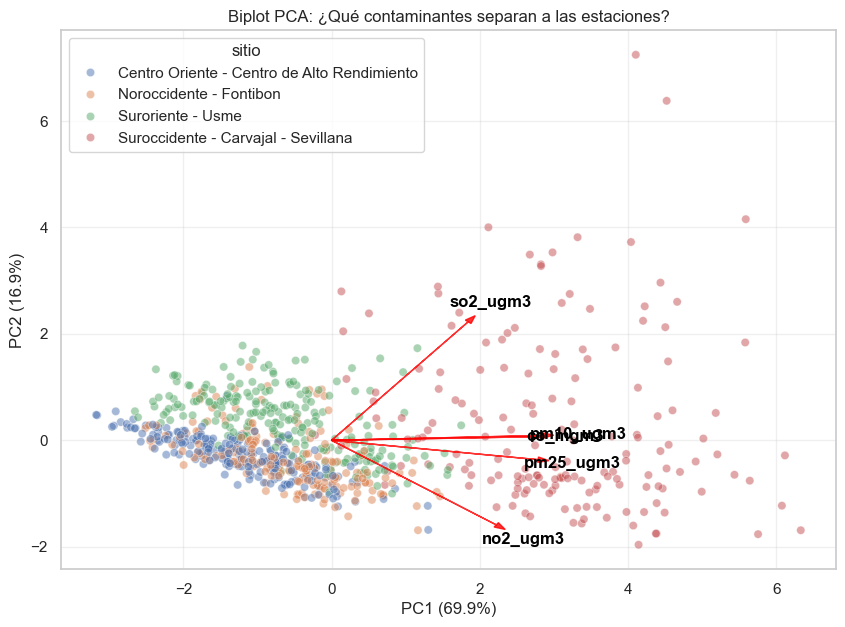

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Estandarizar
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

# 2. Graficar puntos
plt.figure(figsize=(10, 7))
sns.scatterplot(x=components[:,0], y=components[:,1], hue=y, alpha=0.5)

# 3. Graficar vectores (flechas de contaminantes)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
for i, feature in enumerate(pollutants):
    plt.arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3, color='red', alpha=0.8, head_width=0.1)
    plt.text(loadings[i, 0]*3.5, loadings[i, 1]*3.5, feature, color='black', ha='center', va='center', weight='bold')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Biplot PCA: ¿Qué contaminantes separan a las estaciones?')
plt.grid(alpha=0.3)
plt.show()

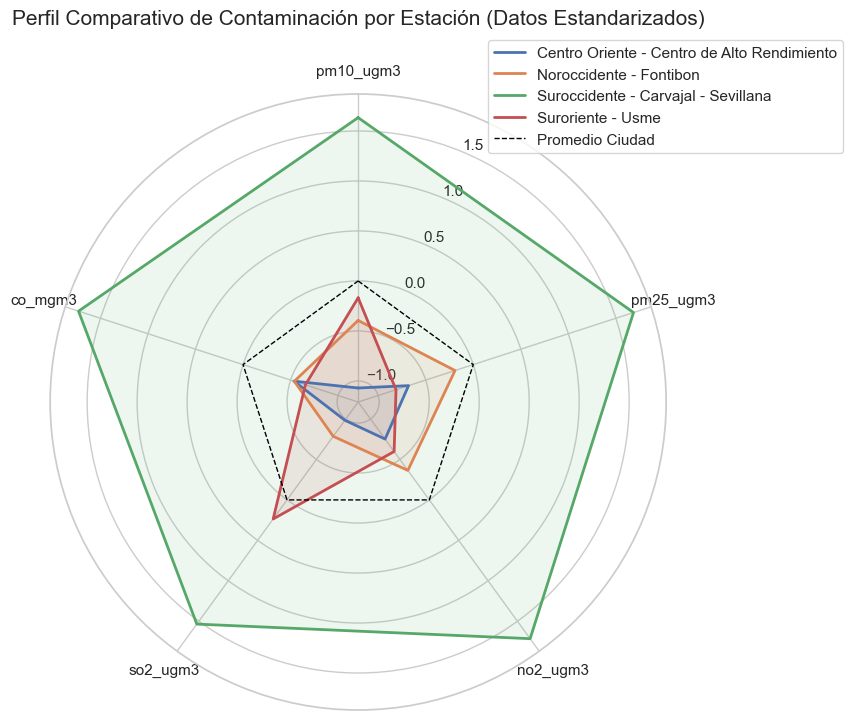

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Preparar los datos (Promedios por sitio)
pollutants = ['pm10_ugm3', 'pm25_ugm3', 'no2_ugm3', 'so2_ugm3', 'co_mgm3']
df_means = df_daily_cleaned.groupby('sitio')[pollutants].mean()

# 2. Estandarizar para que la comparación sea justa (Escala Z-score)
scaler = StandardScaler()
df_means_scaled = pd.DataFrame(
    scaler.fit_transform(df_means),
    columns=pollutants,
    index=df_means.index
)

# 3. Configuración del Gráfico de Araña
labels = np.array(pollutants)
num_vars = len(labels)

# Calcular ángulos para cada eje
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Cerrar el polígono

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Dibujar cada sitio
for sitio in df_means_scaled.index:
    values = df_means_scaled.loc[sitio].values.flatten().tolist()
    values += values[:1] # Cerrar el polígono
    ax.plot(angles, values, linewidth=2, label=sitio)
    ax.fill(angles, values, alpha=0.1)

# Ajustes estéticos
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

# Añadir una línea en el 0 (Promedio de la ciudad)
ax.plot(angles, [0]*(num_vars+1), color='black', linestyle='--', linewidth=1, label='Promedio Ciudad')

plt.title('Perfil Comparativo de Contaminación por Estación (Datos Estandarizados)', size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()


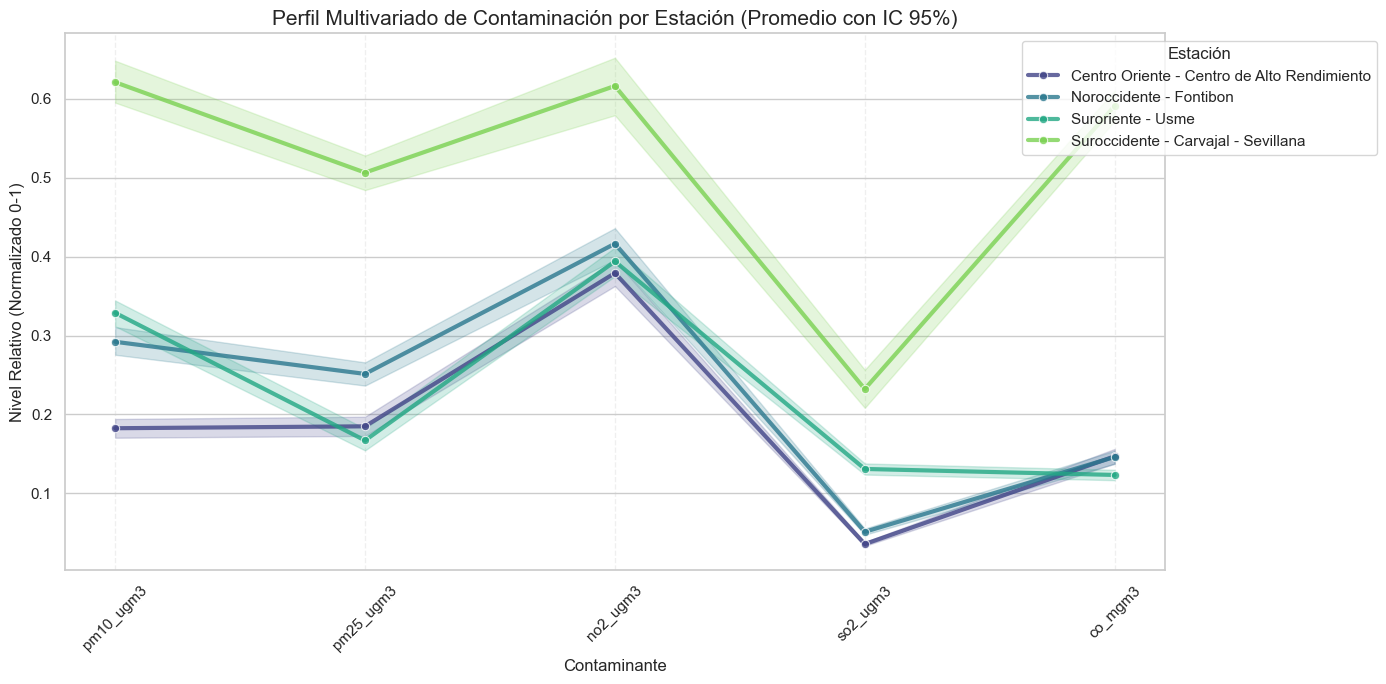

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 1. Preparar y Escalar los datos originales (sin agrupar todavía)
df_parallel = df_daily_cleaned.copy()
scaler_mm = MinMaxScaler()
df_parallel[pollutants] = scaler_mm.fit_transform(df_parallel[pollutants])

# 2. Formatear datos para Seaborn (Melt)
# Necesitamos pasar de formato ancho (columnas por contaminante) a formato largo
df_long = df_parallel.melt(id_vars='sitio', value_vars=pollutants,
                           var_name='Contaminante', value_name='Nivel_Normalizado')

# 3. Graficar con bandas de error (95% de confianza por defecto)
plt.figure(figsize=(14, 7))

# sns.lineplot calcula automáticamente el promedio y el sombreado del error
sns.lineplot(
    data=df_long,
    x='Contaminante',
    y='Nivel_Normalizado',
    hue='sitio',
    marker='o',
    linewidth=3,
    palette='viridis',
    err_style="band", # Esto crea el sombreado de error
    alpha=0.8
)

plt.title('Perfil Multivariado de Contaminación por Estación (Promedio con IC 95%)', fontsize=15)
plt.ylabel('Nivel Relativo (Normalizado 0-1)')
plt.xticks(rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.legend(title='Estación', loc='upper right', bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()


## PARTE C

### 📚 Diccionario de Datos (df_birds)

| Variable | Definición | Unidades |
| :--- | :--- | :--- |
| `SAMPLING EVENT IDENTIFIER` | Identificador único del evento de muestreo de aves | Texto |
| `nearest_station` | Nombre de la estación de monitoreo de calidad del aire más cercana al sitio de observación | Texto |
| `y_copeton` | Variable binaria: 1 si el ave 'Zonotrichia capensis' (Copetón) fue observada, 0 si no | Binaria (0 o 1) |
| `pm10_ugm3` | Material particulado menor a 10 micras | $\mu g/m^3$ |
| `pm25_ugm3` | Material particulado menor a 2.5 micras | $\mu g/m^3$ |
| `no2_ugm3` | Dióxido de Nitrógeno | $\mu g/m^3$ |
| `so2_ugm3` | Dióxido de Azufre | $\mu g/m^3$ |
| `co_mgm3` | Monóxido de Carbono | $mg/m^3$ |


In [25]:
!pip install ipywidgets
!jupyter nbextension enable --py widgetsnbextension

usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: kernel kernelspec migrate run troubleshoot trust

Jupyter command `jupyter-nbextension` not found.


### EDA para el dataset de Copetones (df_birds)

--- 1.1 Calidad de Datos en df_birds ---

--- Nulos por Variable ---
pm10_ugm3     11
pm25_ugm3      4
no2_ugm3     292
so2_ugm3     314
co_mgm3      180
y_copeton      0
dtype: int64

--- Duplicados ---
Registros duplicados: 0

--- Balance de Muestras por Presencia/Ausencia (y_copeton) ---
y_copeton
1    507
0    180
Name: count, dtype: int64

Se eliminaron 327 registros con valores nulos en los contaminantes.

--- Balance de Muestras después de la Limpieza ---
y_copeton
1    275
0     85
Name: count, dtype: int64

### 2. Estadísticas Descriptivas por Presencia/Ausencia


,Ausencia,Presencia
pm10_ugm3_Media,33.537339,32.846315
pm10_ugm3_Mediana,29.643520,29.148390
pm10_ugm3_Varianza,465.029888,474.206658
pm10_ugm3_Std,21.564552,21.776287
pm10_ugm3_CV,0.643001,0.662975
pm10_ugm3_Asimetria,0.396621,0.785216
pm10_ugm3_Curtosis,-0.638264,0.308810
pm25_ugm3_Media,14.240770,13.749868
pm25_ugm3_Mediana,13.191790,12.890300
pm25_ugm3_Varianza,91.990059,79.297662



--- Explorador Interactivo de Métricas (Copetones) ---


interactive(children=(Dropdown(description='Contaminante', options=('pm10_ugm3', 'pm25_ugm3', 'no2_ugm3', 'so2…


### 3. Distribuciones KDE por Presencia/Ausencia


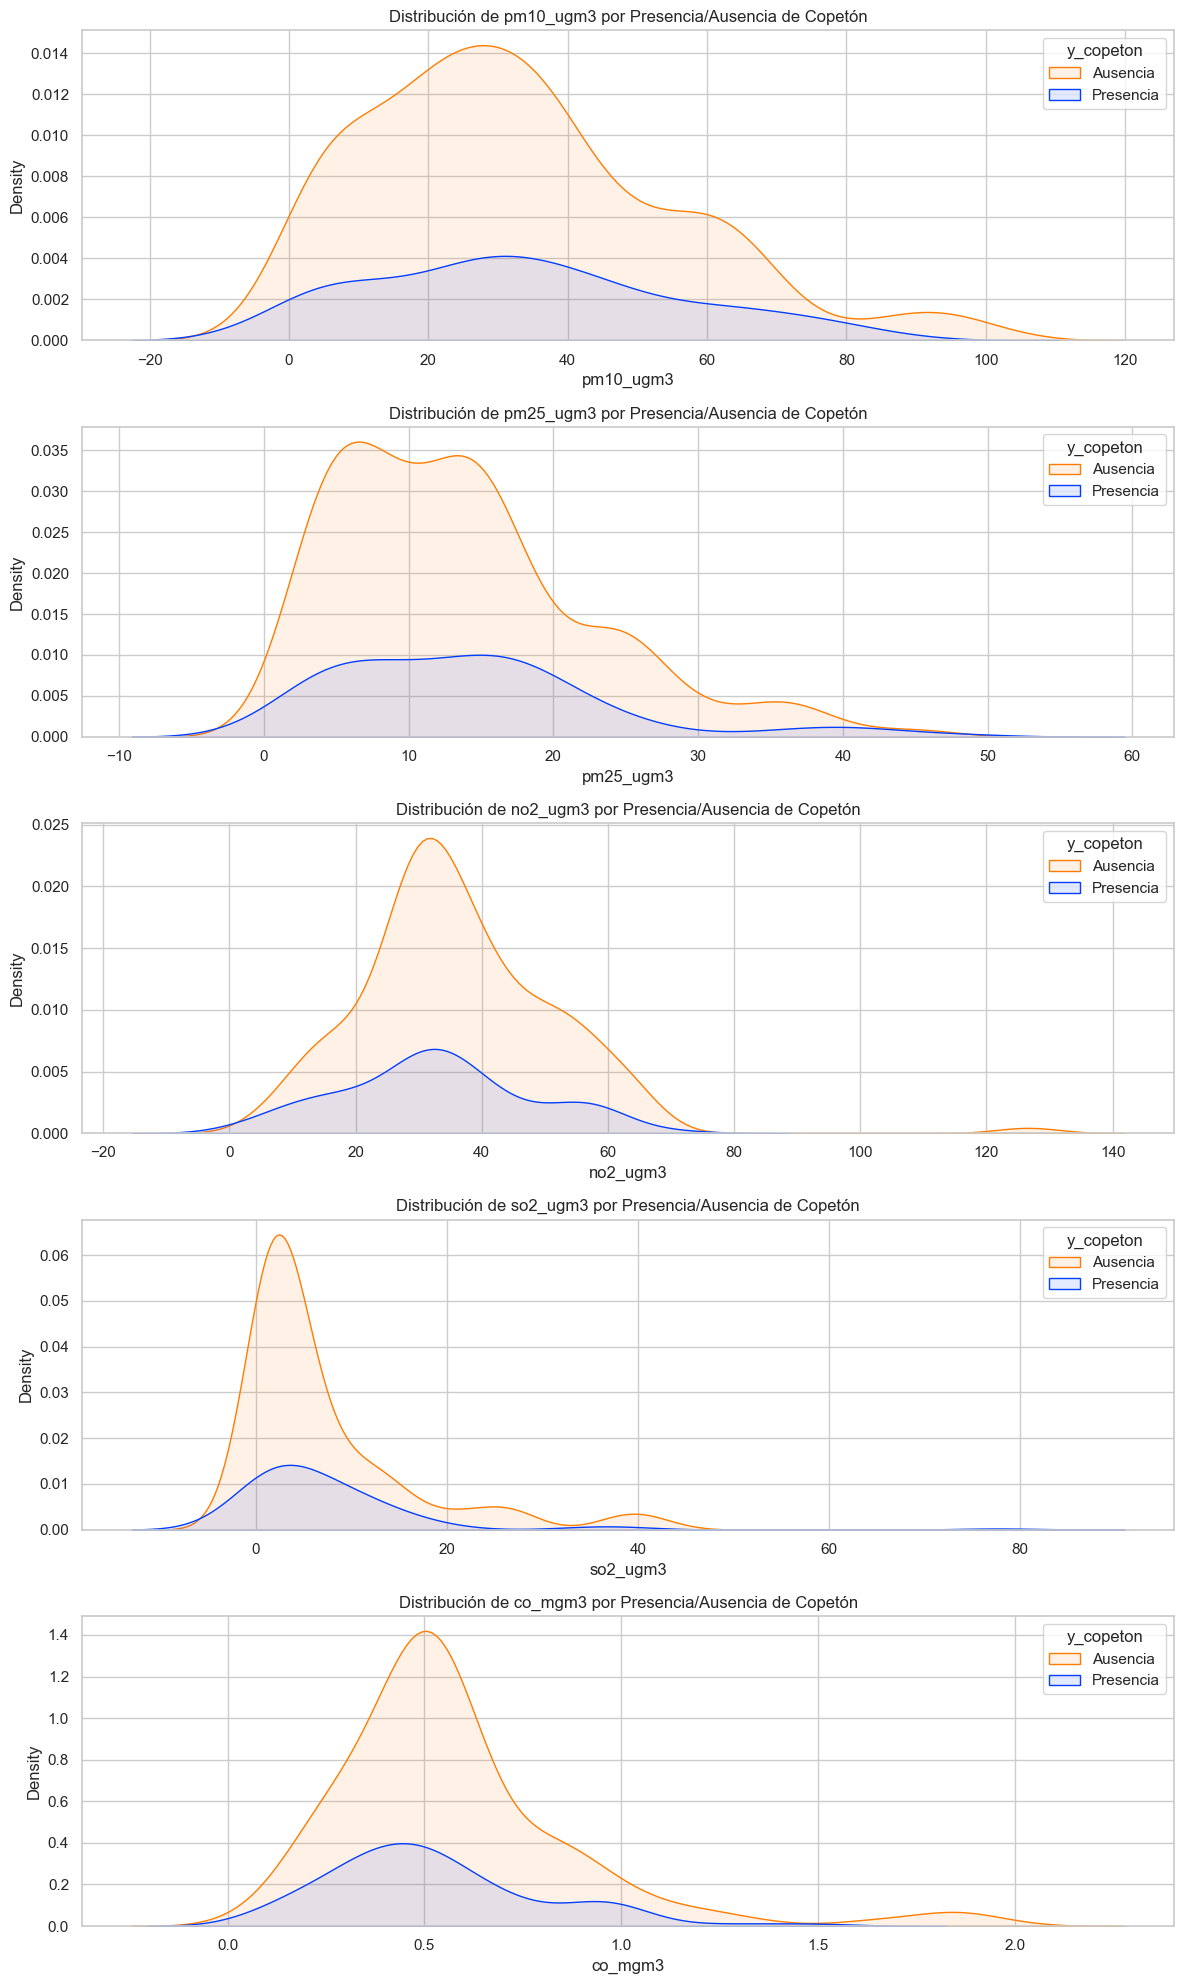


### 4. Boxplots Desagregados por Presencia/Ausencia


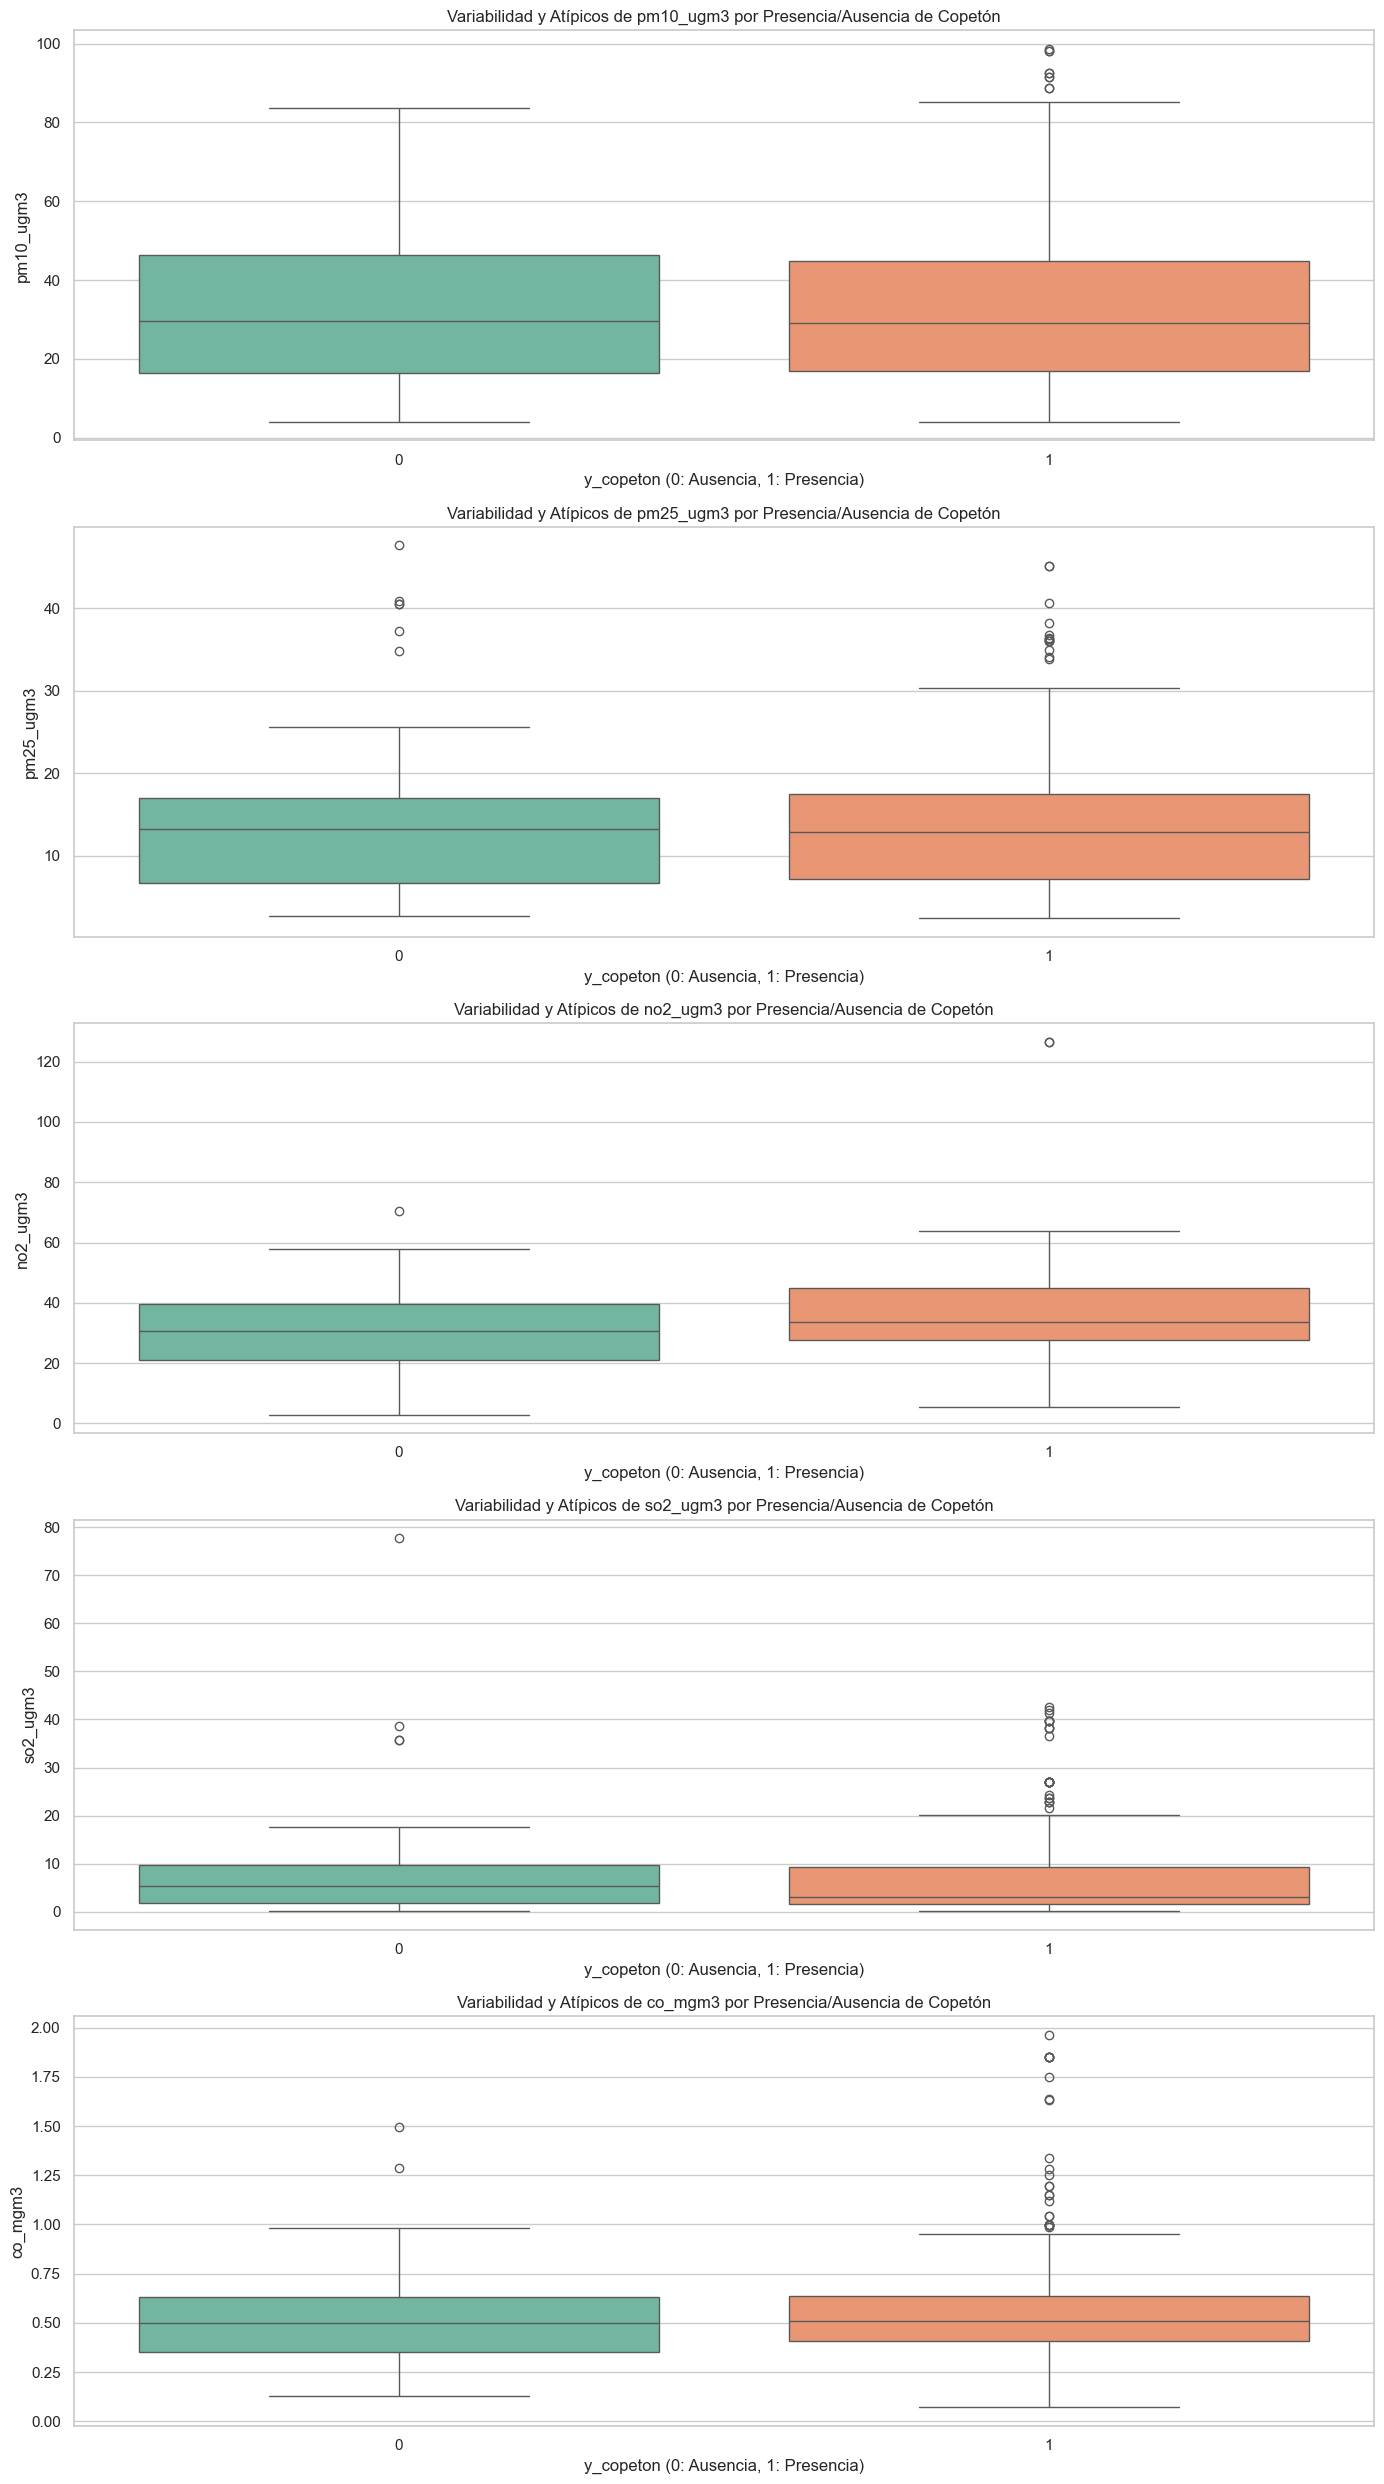


### 5. Comparativa Visual de Matrices de Correlación


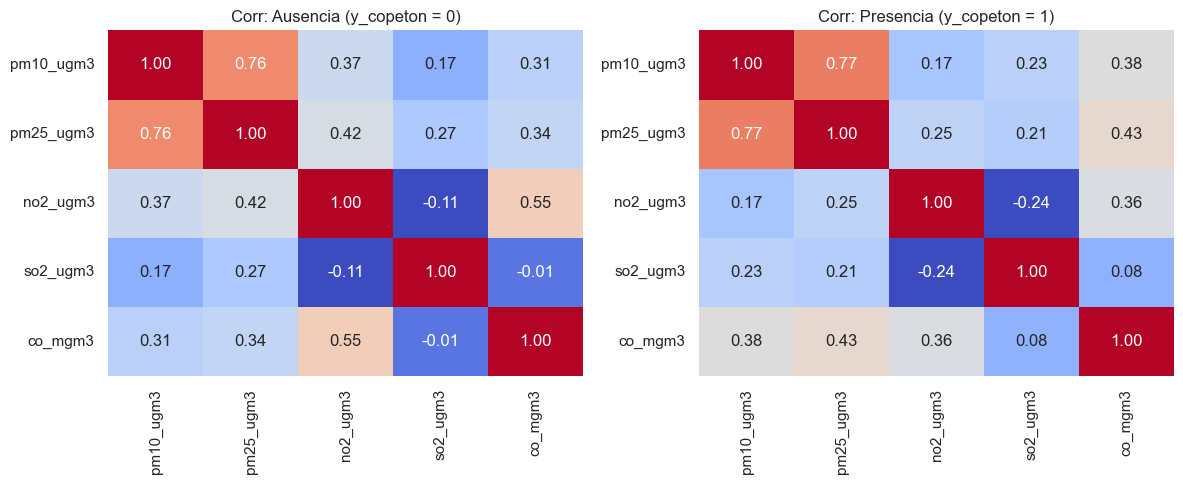

In [26]:
print("### EDA para el dataset de Copetones (df_birds)")

pollutants = ['pm10_ugm3', 'pm25_ugm3', 'no2_ugm3', 'so2_ugm3', 'co_mgm3']
bird_group_col = 'y_copeton'

# --- 1. Calidad de Datos ---
print("\n--- 1.1 Calidad de Datos en df_birds ---")
print("\n--- Nulos por Variable ---")
print(df_birds[pollutants + [bird_group_col]].isnull().sum())

print("\n--- Duplicados ---")
print(f"Registros duplicados: {df_birds.duplicated().sum()}")

print("\n--- Balance de Muestras por Presencia/Ausencia (y_copeton) ---")
print(df_birds[bird_group_col].value_counts())

# Eliminar nulos para análisis posteriores si los hubiera en los contaminantes
df_birds_cleaned = df_birds.dropna(subset=pollutants).copy()
print(f"\nSe eliminaron {len(df_birds) - len(df_birds_cleaned)} registros con valores nulos en los contaminantes.")

# Actualizar el balance después de la limpieza
print("\n--- Balance de Muestras después de la Limpieza ---")
print(df_birds_cleaned[bird_group_col].value_counts())

# --- 2. Estadísticas Descriptivas por Presencia/Ausencia ---
print("\n### 2. Estadísticas Descriptivas por Presencia/Ausencia")

def get_descriptive_stats_birds(group):
    stats_dict = {}
    for col in pollutants:
        data = group[col].dropna()
        if len(data) > 0:
            stats_dict[f'{col}_Media'] = data.mean()
            stats_dict[f'{col}_Mediana'] = data.median()
            stats_dict[f'{col}_Varianza'] = data.var()
            stats_dict[f'{col}_Std'] = data.std()
            stats_dict[f'{col}_CV'] = (data.std() / data.mean()) if data.mean() != 0 else np.nan
            stats_dict[f'{col}_Asimetria'] = stats.skew(data)
            stats_dict[f'{col}_Curtosis'] = stats.kurtosis(data)
    return pd.Series(stats_dict)

df_desc_birds = df_birds_cleaned.groupby(bird_group_col).apply(get_descriptive_stats_birds).T
df_desc_birds.columns = ['Ausencia', 'Presencia'] # Renombrar columnas para mayor claridad
display(df_desc_birds)

# --- PANEL INTERACTIVO (Adaptado para df_birds) ---
metric_map = {
    'Media': 'Media',
    'Mediana': 'Mediana',
    'Varianza': 'Varianza',
    'Desviación Estándar': 'Std',
    'Coef. Variación (CV)': 'CV',
    'Asimetría': 'Asimetria',
    'Curtosis': 'Curtosis'
}

def actualizar_grafico_birds(Contaminante, Metrica):
    suffix = metric_map[Metrica]
    row_label = f"{Contaminante}_{suffix}"

    data_plot = df_desc_birds.loc[row_label].reset_index()
    data_plot.columns = ['Estado', 'Valor']

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x='Estado', y='Valor', data=data_plot, palette='viridis')
    plt.title(f"Comparativa Multivariada: {Metrica} de {Contaminante} (Copetones)", fontsize=14, fontweight='bold')
    plt.xticks(rotation=0)

    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'),
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha = 'center', va = 'center',
                       xytext = (0, 9),
                       textcoords = 'offset points')
    plt.show()

print("\n--- Explorador Interactivo de Métricas (Copetones) ---")
widgets.interact(actualizar_grafico_birds,
                 Contaminante=pollutants,
                 Metrica=list(metric_map.keys()));

# --- 3. Distribuciones KDE por Presencia/Ausencia ---
print("\n### 3. Distribuciones KDE por Presencia/Ausencia")
fig, axes = plt.subplots(len(pollutants), 1, figsize=(12, 4 * len(pollutants)))

for i, pol in enumerate(pollutants):
    sns.kdeplot(data=df_birds_cleaned, x=pol, hue=bird_group_col, palette='bright', fill=True, alpha=0.1, ax=axes[i])
    axes[i].set_title(f"Distribución de {pol} por Presencia/Ausencia de Copetón")
    axes[i].legend(title='y_copeton', labels=['Ausencia', 'Presencia'])

plt.tight_layout()
plt.show()

# --- 4. Boxplots Desagregados por Presencia/Ausencia ---
print("\n### 4. Boxplots Desagregados por Presencia/Ausencia")
fig, axes = plt.subplots(len(pollutants), 1, figsize=(14, 5 * len(pollutants)))

for i, pol in enumerate(pollutants):
    sns.boxplot(data=df_birds_cleaned, x=bird_group_col, y=pol, palette='Set2', ax=axes[i])
    axes[i].set_title(f"Variabilidad y Atípicos de {pol} por Presencia/Ausencia de Copetón")
    axes[i].set_xlabel('y_copeton (0: Ausencia, 1: Presencia)')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# --- 5. Comparativa Visual de Matrices de Correlación ---
print("\n### 5. Comparativa Visual de Matrices de Correlación")

unique_groups = df_birds_cleaned[bird_group_col].unique()
fig, axes = plt.subplots(1, len(unique_groups), figsize=(6 * len(unique_groups), 5))

for i, group_val in enumerate(sorted(unique_groups)): # Sort for consistent order
    data_group = df_birds_cleaned[df_birds_cleaned[bird_group_col] == group_val][pollutants]
    if len(data_group) > 0:
        group_label = 'Presencia' if group_val == 1 else 'Ausencia'
        sns.heatmap(data_group.corr(), annot=True, fmt=".2f", cmap='coolwarm', ax=axes[i], cbar=False)
        axes[i].set_title(f"Corr: {group_label} (y_copeton = {group_val})")

plt.tight_layout()
plt.show()

In [27]:
#actualizar dataset
df_birds_copy= df_birds.copy()
df_birds = df_birds_cleaned.copy()

**SUPUESTOS PARTE C**

In [28]:
print("### Supuestos para la Parte C (Efecto Biológico)")

bird_poll_cols = ['pm10_ugm3', 'pm25_ugm3', 'no2_ugm3', 'so2_ugm3', 'co_mgm3'] # Corrected column names
presencia = df_birds[df_birds['y_copeton'] == 1][bird_poll_cols].dropna()
ausencia = df_birds[df_birds['y_copeton'] == 0][bird_poll_cols].dropna()

print("\n--- 1. Normalidad Multivariada (Prueba de Mardia) ---")
print("   Analizando el grupo de PRESENCIA:")
if len(presencia) > len(bird_poll_cols):
    mardia_presencia = pg.multivariate_normality(presencia)
    print(f"   Normalidad para Presencia: {mardia_presencia.normal} (p={mardia_presencia.pval:.5f})")
else:
    print("   No hay suficientes datos para realizar la prueba de Mardia para el grupo de presencia.")

print("\n   Analizando el grupo de AUSENCIA:")
if len(ausencia) > len(bird_poll_cols):
    mardia_ausencia = pg.multivariate_normality(ausencia)
    print(f"   Normalidad para Ausencia: {mardia_ausencia.normal} (p={mardia_ausencia.pval:.5f})")
else:
    print("   No hay suficientes datos para realizar la prueba de Mardia para el grupo de ausencia.")


print("\n--- 2. Homocedasticidad Multivariada (Prueba M de Box) ---")

# Combinar los datos de presencia y ausencia para Box's M test
# Se necesita una columna para identificar el grupo (y_copeton)
# y unificar las columnas de contaminantes con los nombres originales si no están ya así.

df_birds_subset = df_birds[['y_copeton'] + bird_poll_cols].dropna()

try:
    # Aseguramos que no haya nulos en las variables involucradas
    res_box_m = pg.box_m(data=df_birds_subset, dvs=bird_poll_cols, group='y_copeton')
    display(res_box_m)

    # Acceso corregido al valor booleano de 'equal_cov'
    if res_box_m.loc['box', 'equal_cov']:
        print("\n✅ Las matrices de covarianza son homogéneas (p > 0.05).")
    else:
        print("\n⚠️ Las matrices de covarianza NO son homogéneas. Considera usar estadísticas robustas (Pillai o Lawley-Hotelling) en pruebas como MANOVA.")

except Exception as e:
    print(f"No se pudo realizar la prueba M de Box: {e}")

### Supuestos para la Parte C (Efecto Biológico)

--- 1. Normalidad Multivariada (Prueba de Mardia) ---
   Analizando el grupo de PRESENCIA:
   Normalidad para Presencia: False (p=0.00000)

   Analizando el grupo de AUSENCIA:
   Normalidad para Ausencia: False (p=0.00000)

--- 2. Homocedasticidad Multivariada (Prueba M de Box) ---


,Chi2,df,pval,equal_cov
box,22.174532,15.0,0.103309,True



✅ Las matrices de covarianza son homogéneas (p > 0.05).


### 3.4.1 Parte C: Efecto Biológico (PERMANOVA para Presencia vs Ausencia de Copetón)

Dado que los datos de contaminantes no siguen una distribución normal multivariada (como indicó la prueba de Mardia), la PERMANOVA (Permutational Multivariate Analysis of Variance) es una alternativa robusta y no paramétrica a la prueba T-cuadrada de Hotelling. Esta prueba es especialmente adecuada para datos ecológicos y evalúa si las diferencias entre los grupos (presencia/ausencia de copetón) son significativas en el espacio multivariado de los contaminantes, basándose en una matriz de distancias.

### 3.4.2 Explicación Detallada de PERMANOVA (Presencia vs Ausencia de Copetón)

La PERMANOVA (Permutational Multivariate Analysis of Variance) es una prueba no paramétrica robusta que examina si existen diferencias significativas entre dos o más grupos en el espacio multivariado. A diferencia de MANOVA, no asume normalidad multivariada y funciona bien con datos ecológicos, utilizando matrices de distancia para evaluar la dispersión entre grupos.

**Objetivo:** Determinar si existe una diferencia significativa en el **vector de concentraciones de contaminantes** entre las ubicaciones donde el ave *Zonotrichia capensis* (copetón) está presente y donde está ausente.

#### Planteamiento Formal de las Hipótesis:

*   **Hipótesis Nula ($H_0$):** No hay diferencias significativas en la composición multivariada de los contaminantes atmosféricos entre los sitios con presencia del copetón y los sitios con ausencia del copetón. Es decir, los centros de los grupos (presencia y ausencia) son los mismos en el espacio multivariado de los contaminantes.
    Matemáticamente, se postula que la variabilidad *entre* los grupos es igual o menor que la variabilidad *dentro* de los grupos.
    - $H_0: \text{Los centroides de los grupos en el espacio de distancias son idénticos (es decir, } \mu_1 = \mu_2 = \dots = \mu_g\text{)}$


*   **Hipótesis Alternativa ($H_A$):** Hay diferencias significativas en la composición multivariada de los contaminantes atmosféricos entre los sitios con presencia del copetón y los sitios con ausencia del copetón. Es decir, los centros de los grupos son diferentes en el espacio multivariado de los contaminantes.
    Matemáticamente, se postula que la variabilidad *entre* los grupos es significativamente mayor que la variabilidad *dentro* de los grupos.
    - $H_1: \text{Al menos un centroide es significativamente diferente (es decir, al menos un } \mu_i \neq \mu_j\text{)}$

#### Paso a Paso del Cálculo (Conceptual):

La PERMANOVA se basa en la partición de la variabilidad total en una matriz de distancias. Aunque el proceso exacto puede ser complejo, conceptualmente sigue estos pasos:

1.  **Definir las Variables:**
    *   **Variables Dependientes (respuestas):** Las concentraciones de los contaminantes (`pm10_ugm3`, `pm25_ugm3`, `no2_ugm3`, `so2_ugm3`, `co_mgm3`).
    *   **Variable Independiente (factor):** La presencia o ausencia del copetón (`y_copeton`).

2.  **Calcular una Matriz de Distancias:**
    *   Se calcula la distancia multivariada entre **cada par de observaciones** en el conjunto de datos. La **distancia euclidiana** es una métrica común y adecuada para este tipo de datos.
    *   *Código:* `dist_matrix_birds = DistanceMatrix(pdist(X_birds, metric='euclidean'), ids=X_birds.index)`

3.  **Partición de la Variabilidad (pseudo-F):**
    *   Similar a un ANOVA univariado, la PERMANOVA descompone la variabilidad total en la matriz de distancias en dos componentes:
        *   **Variabilidad dentro de los grupos (SSW):** La suma de las distancias al centroide de cada grupo.
        *   **Variabilidad entre los grupos (SSA):** La suma de las distancias entre los centroides de los grupos y el centroide general.
    *   A partir de estas variabilidades, se calcula un estadístico **pseudo-F**, que es análogo al estadístico F en ANOVA y MANOVA. Un valor alto de pseudo-F sugiere que la variabilidad entre los grupos es grande en comparación con la variabilidad dentro de los grupos.

4.  **Permutaciones para Obtener el p-valor:**
    *   Dado que no asume una distribución conocida para los datos, la PERMANOVA obtiene su p-valor a través de un proceso de permutación. Esto implica:
        *   **Mezclar aleatoriamente las etiquetas de los grupos** (presencia/ausencia) entre las observaciones, manteniendo la matriz de distancias fija.
        *   **Recalcular el estadístico pseudo-F** para cada permutación.
        *   **Repetir este proceso un gran número de veces** (ej., 999 o 9999 permutaciones) para construir una distribución nula del estadístico pseudo-F.
    *   El p-valor se calcula como la proporción de estadísticos pseudo-F obtenidos en las permutaciones que son iguales o mayores que el estadístico pseudo-F observado con los datos reales.
    *   *Código:* `results_permanova_birds = permanova(dist_matrix_birds, grouping=y_birds, permutations=999)`

5.  **Decisión:**
    *   Si el `p-value < alpha` (nivel de significancia, comúnmente 0.05), se **rechaza la hipótesis nula**. Esto significa que hay evidencia suficiente para concluir que existe una diferencia significativa en el vector de contaminantes entre las ubicaciones con presencia y ausencia de copetones.
    *   Si el `p-value >= alpha`, **no se rechaza la hipótesis nula**. Esto significa que no hay evidencia suficiente para concluir que existe una diferencia significativa en el vector de contaminantes entre las ubicaciones con presencia y ausencia de copetones, según esta prueba robusta.

En tu caso, el resultado de la PERMANOVA para Presencia vs Ausencia del Copetón fue un **p-valor = 0.41800**. Como este valor es mayor que 0.05, la conclusión es que **no hay diferencias significativas**.

In [29]:
from skbio.stats.distance import permanova, DistanceMatrix
from scipy.spatial.distance import pdist

print("### Ejecutando PERMANOVA para Presencia vs Ausencia del Copetón")

bird_poll_cols = ['pm10_ugm3', 'pm25_ugm3', 'no2_ugm3', 'so2_ugm3', 'co_mgm3']

# Asegurarse de usar el DataFrame limpio de aves
df_birds_cleaned = df_birds.dropna(subset=bird_poll_cols).copy()

# Preparar los datos para PERMANOVA
# Extraer las variables dependientes (contaminantes)
X_birds = df_birds_cleaned[bird_poll_cols]

# Extraer la variable independiente (grupo: presencia/ausencia)
y_birds = df_birds_cleaned['y_copeton']

# Calcular la matriz de distancias (Euclidiana es común para PERMANOVA)
print("Calculando la matriz de distancias (Euclidiana) para los datos de aves...")
dist_matrix_birds = DistanceMatrix(pdist(X_birds, metric='euclidean'), ids=X_birds.index)

# Realizar el PERMANOVA
print("Calculando PERMANOVA para comparar Presencia vs Ausencia...")
results_permanova_birds = permanova(dist_matrix_birds, grouping=y_birds, permutations=999) # 999 permutaciones es un valor común

display(results_permanova_birds)

# Interpretar los resultados
alpha = 0.05
if results_permanova_birds['p-value'] < alpha:
    print(f"\n✅ El PERMANOVA es estadísticamente significativo (p = {results_permanova_birds['p-value']:.5f} < {alpha:.3f}).")
    print("Esto sugiere que hay diferencias significativas en las concentraciones de contaminantes entre las ubicaciones con presencia y ausencia de copetones.")
else:
    print(f"\n❌ El PERMANOVA NO es estadísticamente significativo (p = {results_permanova_birds['p-value']:.5f} >= {alpha:.3f}).")
    print("Esto sugiere que no hay diferencias significativas en las concentraciones de contaminantes entre las ubicaciones con presencia y ausencia de copetones, según esta prueba robusta.")

### Ejecutando PERMANOVA para Presencia vs Ausencia del Copetón
Calculando la matriz de distancias (Euclidiana) para los datos de aves...
Calculando PERMANOVA para comparar Presencia vs Ausencia...


method name               PERMANOVA
test statistic name        pseudo-F
sample size                     360
number of groups                  2
test statistic             0.863557
p-value                       0.413
number of permutations          999
Name: PERMANOVA results, dtype: object


❌ El PERMANOVA NO es estadísticamente significativo (p = 0.41300 >= 0.050).
Esto sugiere que no hay diferencias significativas en las concentraciones de contaminantes entre las ubicaciones con presencia y ausencia de copetones, según esta prueba robusta.


### 🧪 Metodología: Inferencia Multivariada Robusta (Test de Permutación)

Para evaluar la diferencia entre los vectores de medias de contaminación, se implementó una variante no paramétrica de la prueba T-cuadrada de Hotelling. Este enfoque es superior a la prueba paramétrica tradicional cuando los datos presentan distribuciones asimétricas, valores atípicos o desbalance en los grupos, características presentes en nuestro caso. Se decidió realizarla como una prueba adicional y complementaria al PERMANOVA para corroborar los resultados y aportar mayor robustez a las conclusiones.

#### 1. Formulación de Hipótesis Multivariada
Se comparan los perfiles atmosféricos de los grupos (ej. Presencia vs. Ausencia de fauna) definidos por sus vectores de medias de $p$ dimensiones:

*   **Hipótesis Nula ($H_0$):** Los centroides de contaminación son idénticos. Es decir, $\mu_1 = \mu_2$.
*   **Hipótesis Alternativa ($H_A$):** Existe una diferencia significativa en el perfil multivariado. Es decir, $\mu_1 \neq \mu_2$.

#### 2. Estadístico de Prueba ($\mathbf{T^2}$ de dos muestras)
El estadístico mide la distancia cuadrática de Mahalanobis entre los promedios de los grupos, ponderada por la variabilidad conjunta:

$$ \mathbf{T^2} = \frac{N_1 N_2}{N_1 + N_2} (\bar{\mathbf{X}}_1 - \bar{\mathbf{X}}_2)^T \mathbf{S}_p^{-1} (\bar{\mathbf{X}}_1 - \bar{\mathbf{X}}_2) $$

Donde $\mathbf{S}_p$ es la matriz de covarianza combinada, que captura las correlaciones internas entre los 5 contaminantes.

#### 3. Simulación de la Distribución Nula (Monte Carlo)
Dado que no se cumple el supuesto de Normalidad Multivariada, no se utiliza la distribución $F$ teórica. En su lugar:

*   Se agrupan todas las observaciones en una sola población (bajo la premisa de $H_0$).
*   Se realizan $B$ (ej. 5000) permutaciones aleatorias de las etiquetas de los grupos, manteniendo los tamaños de muestra originales ($N_1$, $N_2$).
*   Para cada iteración, se calcula un estadístico pseudo-$T^2$, generando una distribución empírica del azar.

#### 4. Estimación del p-valor Empírico
El valor p se calcula mediante la proporción de veces que el azar igualó o superó la diferencia observada en los datos reales:

$$ p = \frac{\text{Número de } T^2_{\text{perm}} \ge T^2_{\text{observado}} + 1}{B + 1} $$

El ajuste $+1$ en el numerador y denominador actúa como un estimador conservador para evitar sesgos en el límite de la distribución.

#### 5. Justificación del Método
Este procedimiento garantiza la validez de la inferencia ante la heterocedasticidad (varianzas desiguales) y el fuerte desbalance muestral, proporcionando una conclusión estadísticamente honesta sobre la existencia de brechas ambientales o efectos biológicos.

### 3.4.3 Parte C: Test de Permutación Hotelling T2 (Efecto Biológico - Estandarizado)
Realizando 5000 permutaciones con datos estandarizados...

--- Resultado del Test de Permutación (Estandarizado) ---
Estadístico T2 Observado: 5.5635
P-valor (basado en 5000 permutaciones): 0.367726
Conclusión: NO SIGNIFICATIVO (p >= 0.05). No hay evidencia de diferencia en el perfil.


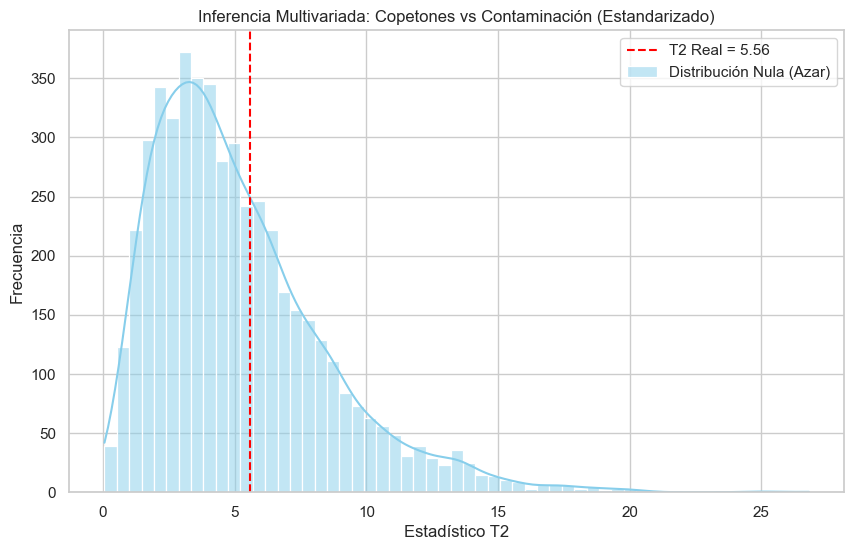

In [30]:
from sklearn.preprocessing import StandardScaler

print("### 3.4.3 Parte C: Test de Permutación Hotelling T2 (Efecto Biológico - Estandarizado)")

bird_poll_cols = ['pm10_ugm3', 'pm25_ugm3', 'no2_ugm3', 'so2_ugm3', 'co_mgm3']

# 1. Limpieza y preparación
df_birds_cleaned = df_birds.dropna(subset=bird_poll_cols).copy()

# 2. ESTANDARIZACIÓN: Crucial para que PM10 no opaque al CO
scaler = StandardScaler()
df_birds_cleaned[bird_poll_cols] = scaler.fit_transform(df_birds_cleaned[bird_poll_cols])

# Extraer los datos para Presencia y Ausencia tras estandarizar
presencia = df_birds_cleaned[df_birds_cleaned['y_copeton'] == 1][bird_poll_cols]
ausencia = df_birds_cleaned[df_birds_cleaned['y_copeton'] == 0][bird_poll_cols]

# Verificar si hay suficientes datos en cada grupo
if len(presencia) <= len(bird_poll_cols) or len(ausencia) <= len(bird_poll_cols):
    print("No hay suficientes datos en uno de los grupos para realizar la prueba.")
else:
    # 3. Calcular el estadístico T2 observado (con datos estandarizados)
    observed_t2, _, _ = hotelling_t2_two_sample(presencia, ausencia)

    # 4. Implementar el test de permutación
    n_permutations = 5000
    permuted_t2_stats = []

    # Combinar los datos para la aleatorización
    combined_data_values = pd.concat([presencia, ausencia], ignore_index=True)
    n_presencia = len(presencia)
    n_total = len(combined_data_values)

    print(f"Realizando {n_permutations} permutaciones con datos estandarizados...")
    for _ in range(n_permutations):
        # Generar índices aleatorios (mantiene el desbalance original)
        indices = np.random.permutation(n_total)

        permuted_presencia = combined_data_values.iloc[indices[:n_presencia]]
        permuted_ausencia = combined_data_values.iloc[indices[n_presencia:]]

        try:
            t2_perm, _, _ = hotelling_t2_two_sample(permuted_presencia, permuted_ausencia)
            permuted_t2_stats.append(t2_perm)
        except np.linalg.LinAlgError:
            continue

    permuted_t2_stats = np.array(permuted_t2_stats)

    # 5. Calcular el p-valor empírico (ajuste +1 para evitar p=0)
    p_value_perm = (np.sum(permuted_t2_stats >= observed_t2) + 1) / (len(permuted_t2_stats) + 1)

    print(f"\n--- Resultado del Test de Permutación (Estandarizado) ---")
    print(f"Estadístico T2 Observado: {observed_t2:.4f}")
    print(f"P-valor (basado en {len(permuted_t2_stats)} permutaciones): {p_value_perm:.6f}")

    # 6. Decisión
    alpha = 0.05
    if p_value_perm < alpha:
        print(f"Conclusión: SIGINIFICATIVO (p < {alpha}). El perfil de contaminación es distinto donde hay copetones.")
    else:
        print(f"Conclusión: NO SIGNIFICATIVO (p >= {alpha}). No hay evidencia de diferencia en el perfil.")

    # 7. Visualización
    plt.figure(figsize=(10, 6))
    sns.histplot(permuted_t2_stats, kde=True, color='skyblue', label='Distribución Nula (Azar)')
    plt.axvline(observed_t2, color='red', linestyle='--', label=f'T2 Real = {observed_t2:.2f}')
    plt.title('Inferencia Multivariada: Copetones vs Contaminación (Estandarizado)')
    plt.xlabel('Estadístico T2')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.show()


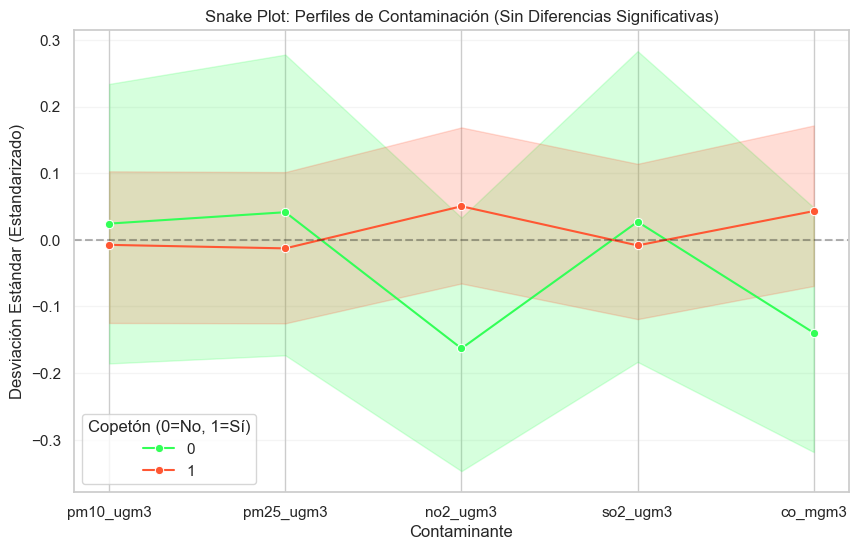

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Estandarizar para que el perfil sea comparable
scaler = StandardScaler()
df_std = df_birds_cleaned.copy()
df_std[bird_poll_cols] = scaler.fit_transform(df_std[bird_poll_cols])

# 2. Convertir a formato largo para graficar con bandas de confianza
df_long = df_std.melt(id_vars='y_copeton', value_vars=bird_poll_cols,
                      var_name='Contaminante', value_name='Z-Score')

# 3. Graficar Snake Plot con intervalos de confianza (95%)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_long, x='Contaminante', y='Z-Score', hue='y_copeton',
             marker='o', err_style="band", palette=['#33FF57', '#FF5733'])

plt.axhline(0, color='black', linestyle='--', alpha=0.3) # Referencia: promedio ciudad
plt.title('Snake Plot: Perfiles de Contaminación (Sin Diferencias Significativas)')
plt.ylabel('Desviación Estándar (Estandarizado)')
plt.legend(title='Copetón (0=No, 1=Sí)')
plt.grid(axis='y', alpha=0.2)
plt.show()
